Sample: 186 rows, 106 firms

Best alpha: 4.94
R² (in-sample): 0.545

Coefficients:
  * ICB Industry name_Technology                    5.099  [3.282, 6.386]
  * log_Assets                                      2.438  [1.951, 3.066]
  * region_Copenhagen area                          1.836  [1.020, 2.682]
  * ICB Industry name_Health Care                   1.449  [0.120, 2.757]
  * Age                                             1.030  [0.234, 1.572]
    ICB Industry name_Telecommunications            0.788  [-0.520, 2.303]
  * year_2025                                       0.786  [0.282, 1.324]
    ICB Industry name_Energy                        0.728  [-0.295, 2.009]
    region_Funen                                    0.392  [-0.645, 1.367]
    region_Jutland major                            0.180  [-0.666, 1.096]
    log_Revenue                                    -0.296  [-0.891, 0.273]
    ICB Industry name_Financials                   -0.393  [-1.629, 0.808]
    ICB Industry name_I

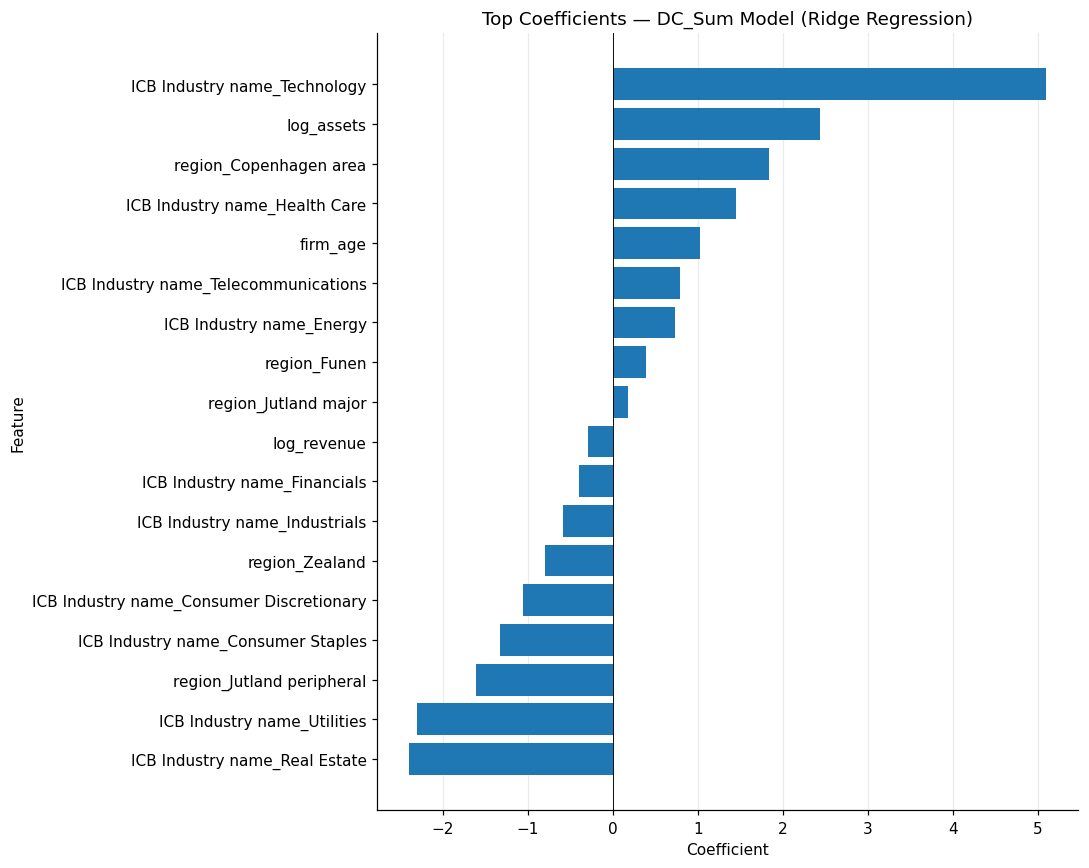

Saved: fig_ridge_dc_sorted.png


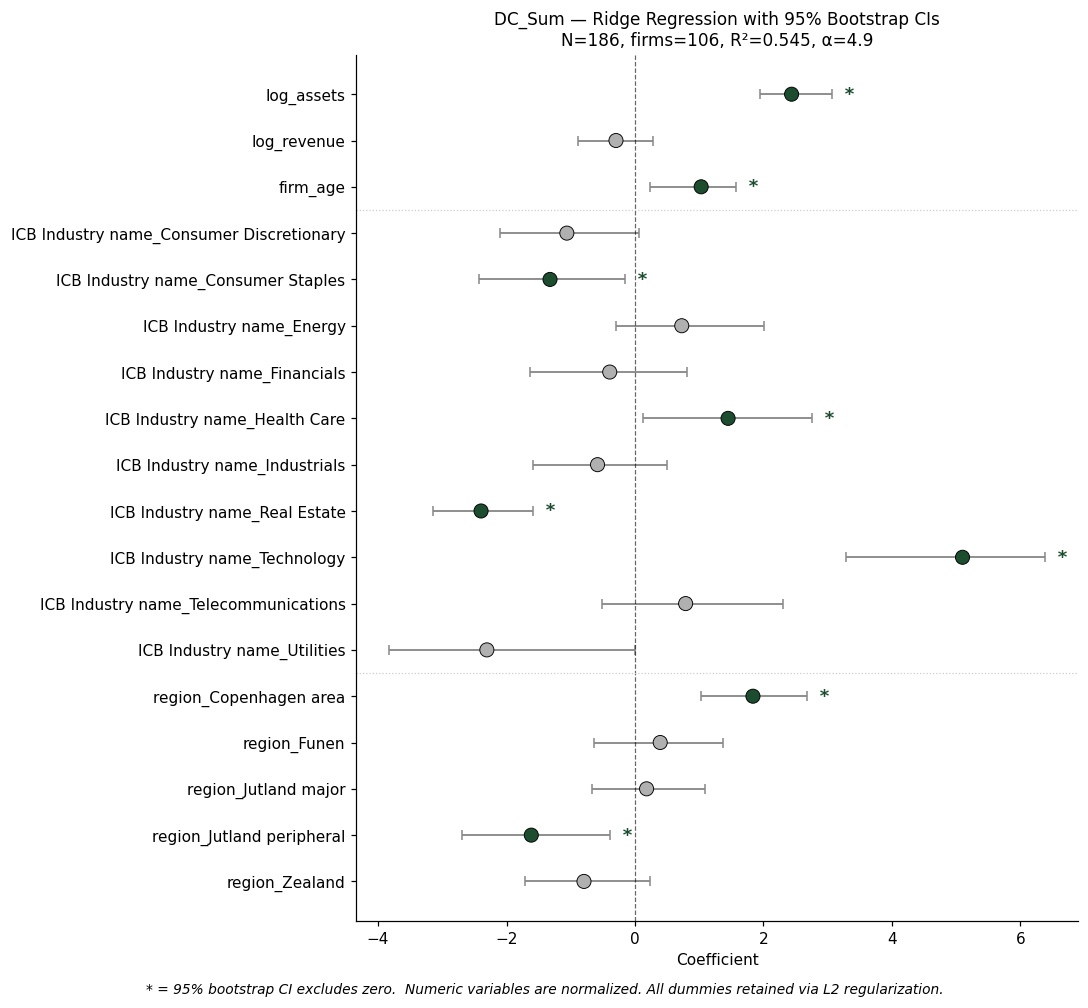

Saved: fig_ridge_dc_detailed.png

Done. R² = 0.545, alpha = 4.94


In [11]:
"""
RQ2: Ridge regression (L2 regularized) for DC_Sum.

Key difference from OLS: no reference category dropped.
All industry and region dummies are included. 
Ridge regularization handles the collinearity that would break plain OLS.

Numeric predictors are normalized so coefficients are comparable.
Optimal regularization strength (alpha) selected via GroupKFold CV.

Outputs:
  - Sorted bar chart of coefficients (matching requested style)
  - Coefficient plot with 95% bootstrap CIs and significance markers
  - CSV of all coefficients
"""

#Imports and packages
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})



#Load + clean
df = pd.read_csv('Master.csv', sep=';', encoding='utf-8')

def clean_num(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().replace(',', '').replace(' ', '').replace('\xa0', '')
    if s in ('', 'nan', 'None', '-', 'N/A', 'NA'): return np.nan
    try: return float(s)
    except ValueError: return np.nan

for col in ['Total Assets Reported', 'Revenue']:
    df[col] = df[col].apply(clean_num)

    
# Convert Date of Incorporation into a year  
def parse_year(s):
    if pd.isna(s): return np.nan
    m = re.search(r'(\d{4})', str(s))
    return int(m.group(1)) if m else np.nan

df['IncYear'] = df['Date of Incorporation'].apply(parse_year)
df['Age']     = 2025 - df['IncYear']


#Attempt forward- and backward filling of Revenue and Total Assets Reported
df = df.sort_values(['Identifier', 'Year']).reset_index(drop=True)
for col in ['Total Assets Reported', 'Revenue']:
    df[col] = df.groupby('Identifier')[col].ffill().bfill()
    
#Turn Revenue and Total Assets Reported into log values
df['log_Assets']  = np.log1p(df['Total Assets Reported'])
df['log_Revenue'] = np.log1p(df['Revenue'])

#Geographic grouping
CITY_TO_REGION = {
    'KOEBENHAVN K': 'Copenhagen area', 'KOEBENHAVN V': 'Copenhagen area',
    'KOEBENHAVN S': 'Copenhagen area', 'KOEBENHAVN': 'Copenhagen area',
    'Copenhagen': 'Copenhagen area', 'COPENHAGEN': 'Copenhagen area',
    'Frederiksberg': 'Copenhagen area', 'Hellerup': 'Copenhagen area',
    'Charlottenlund': 'Copenhagen area', 'Ballerup': 'Copenhagen area',
    'Soeborg': 'Copenhagen area', 'BROENDBY': 'Copenhagen area',
    'Herlev': 'Copenhagen area', 'Kastrup': 'Copenhagen area',
    'Valby': 'Copenhagen area', 'Bagsvaerd': 'Copenhagen area',
    'Glostrup': 'Copenhagen area', 'Hvidovre': 'Copenhagen area',
    'RODOVRE': 'Copenhagen area', 'ROEDOVRE': 'Copenhagen area',
    'Gentofte': 'Copenhagen area', 'ALLEROD': 'Copenhagen area',
    'ALLEROED': 'Copenhagen area', 'Hoersholm': 'Copenhagen area',
    'Humlebaek': 'Copenhagen area', 'Birkeroed': 'Copenhagen area',
    'Vedbaek': 'Copenhagen area', 'SMOERSUM': 'Copenhagen area',
    'SMOERUM': 'Copenhagen area', 'Hedehusene': 'Copenhagen area',
    'Albertslund': 'Copenhagen area',
    'Roskilde': 'Zealand', 'Greve': 'Zealand', 'Ringsted': 'Zealand',
    'SKAELSKOER': 'Zealand', 'Koge': 'Zealand', 'Fakse': 'Zealand',
    'Nakskov': 'Zealand', 'Stege': 'Zealand','Holbæk': 'Zealand',
    'Odense': 'Funen', 'Svendborg': 'Funen', 'Faaborg': 'Funen',
    'Soendersoe': 'Funen',
    'Aarhus': 'Jutland major', 'Aalborg': 'Jutland major',
    'Noerresundby': 'Jutland major', 'Fredericia': 'Jutland major',
    'Horsens': 'Jutland major', 'Herning': 'Jutland major',
    'Silkeborg': 'Jutland major', 'Holstebro': 'Jutland major',
    'Frederikshavn': 'Jutland major', 'Aabenraa': 'Jutland major',
    'VIBY J': 'Jutland major',
    'Struer': 'Jutland peripheral', 'Tjele': 'Jutland peripheral',
    'Pandrup': 'Jutland peripheral', 'Grenaa': 'Jutland peripheral',
    'Tilst': 'Jutland peripheral', 'THYHOLM': 'Jutland peripheral',
    'Rinkobing': 'Jutland peripheral', 'Vejen': 'Jutland peripheral',
    'Skjern': 'Jutland peripheral','Billund': 'Jutland peripheral'
}

def map_region(city):
    if pd.isna(city): return 'Unknown'
    return CITY_TO_REGION.get(str(city).strip(), 'Other')

df['Region'] = df['City of Headquarters'].apply(map_region)


#Prepare, filter, and build design matrix
df = df[df['Year'].isin([2024, 2025])].copy()
df = df.rename(columns={'ICB Industry name': 'Industry'})

mdf = df.dropna(subset=['DC_Sum', 'log_Assets', 'log_Revenue', 'Age',
                        'Industry', 'Region']).copy()

print(f"Sample: {len(mdf)} rows, {mdf['Identifier'].nunique()} firms\n")

#Numeric variables (will be normalized by StandardScaler)
num_cols = ['log_Assets', 'log_Revenue', 'Age']

# One-hot encoding (dummy creation)
ind_dum = pd.get_dummies(mdf['Industry'], prefix='ICB Industry name').astype(float)
reg_dum = pd.get_dummies(mdf['Region'],   prefix='region').astype(float)
yr_dum  = pd.get_dummies(mdf['Year'],     prefix='year').astype(float)

#Concatenate into one big feature matrix
X_df = pd.concat([
    mdf[num_cols].reset_index(drop=True),
    ind_dum.reset_index(drop=True),
    reg_dum.reset_index(drop=True),
    yr_dum.reset_index(drop=True),
], axis=1)

#Defining target, and grouping firms by identifier for later cross-validation
y      = mdf['DC_Sum'].astype(float).values
groups = mdf['Identifier'].values
feat   = list(X_df.columns)

# Normalizing numeric columns; leave dummies as 0/1
scaler = StandardScaler()
X_scaled = X_df.copy()
X_scaled[num_cols] = scaler.fit_transform(X_df[num_cols])
X = X_scaled.values

#Defining test-values for alpha 
alphas = np.logspace(-2, 4, 50)

#Testing optimal alpha value with both firm-years of every firm grouped
gkf = GroupKFold(n_splits=5)

ridge = RidgeCV(alphas=alphas, cv=gkf.split(X, y, groups=groups),
                scoring='r2')
ridge.fit(X, y)

#Printing discovered values for alpha and R^2
print(f"Best alpha: {ridge.alpha_:.2f}")
print(f"R² (in-sample): {ridge.score(X, y):.3f}\n")


#Sort coefficients in descending order for graphing
coef_df = pd.DataFrame({
    'feature': feat,
    'coef': ridge.coef_,
}).sort_values('coef', ascending=False).reset_index(drop=True)



#500 bootstraps for coefficients with a seed for reproducibility
np.random.seed(42)
n_boot = 500
boot_coefs = np.zeros((n_boot, len(feat)))

for b in range(n_boot):
    idx = np.random.choice(len(y), size=len(y), replace=True)
    ridge_b = RidgeCV(alphas=[ridge.alpha_])  # use same alpha
    ridge_b.fit(X[idx], y[idx])
    boot_coefs[b] = ridge_b.coef_

#Define the 2.5th and 97.5th percentiles for confidence intervals    
ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

#
coef_full = pd.DataFrame({
    'feature': feat,
    'coef': ridge.coef_,
    'ci_lo': ci_lo,
    'ci_hi': ci_hi,
})
# Mark significance: CI doesn't cross zero
coef_full['significant'] = ~((coef_full['ci_lo'] <= 0) & (coef_full['ci_hi'] >= 0))

#Print coefficients and define as significant if CI doesn't cross zero
print("Coefficients:")
for _, r in coef_full.sort_values('coef', ascending=False).iterrows():
    sig = '*' if r['significant'] else ' '
    print(f"  {sig} {r['feature']:<45} {r['coef']:>7.3f}  "
          f"[{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]")

coef_full.to_csv('rq2_ridge_dc.csv', index=False)


#Pretty label helper
def pretty_feat(name):
    repl = {'log_Assets': 'log_assets', 'log_Revenue': 'log_revenue', 'Age': 'firm_age'}
    if name in repl: return repl[name]
    return name


#Sorted bar chart
plot_df = coef_full.copy()
# Exclude year dummies from bar chart
plot_df = plot_df[~plot_df['feature'].str.startswith('year_')].copy()
plot_df = plot_df.sort_values('coef', ascending=True)
labels = [pretty_feat(f) for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, plot_df['coef'].values, color='#1f77b4', edgecolor='none')
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Coefficient')
ax.set_ylabel('Feature')
ax.set_title('Top Coefficients — DC_Sum Model (Ridge Regression)', fontsize=12)
ax.grid(axis='x', linestyle='-', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_ridge_dc_sorted.png', bbox_inches='tight')
plt.show()
print('Saved: fig_ridge_dc_sorted.png')


#Coefficient plot with bootstrap 95% CIs
def sig_color(row):
    if row['significant'] and row['coef'] > 0: return '#1b4d2e'
    if row['significant'] and row['coef'] < 0: return '#1b4d2e'
    return '#b0b0b0'

# Order numeric, industry, and region
num_feats = [f for f in feat if f in num_cols]
ind_feats = [f for f in feat if f.startswith('ICB Industry name_')]
reg_feats = [f for f in feat if f.startswith('region_')]
ordered = num_feats + ind_feats + reg_feats

plot_tbl = coef_full.set_index('feature').loc[ordered]
ypos = np.arange(len(ordered))[::-1]
colors = [sig_color(plot_tbl.loc[f]) for f in ordered]

fig, ax = plt.subplots(figsize=(10, 9))
ax.errorbar(plot_tbl['coef'], ypos,
            xerr=[plot_tbl['coef'] - plot_tbl['ci_lo'],
                  plot_tbl['ci_hi'] - plot_tbl['coef']],
            fmt='o', ecolor='#888', elinewidth=1.2, capsize=3,
            mfc='white', mec='none', zorder=2)
ax.scatter(plot_tbl['coef'], ypos, s=85, c=colors, zorder=3,
           edgecolor='black', linewidth=0.6)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_yticks(ypos)
ax.set_yticklabels([pretty_feat(f) for f in ordered])

for i, f in enumerate(ordered):
    if plot_tbl.loc[f, 'significant']:
        ax.text(plot_tbl.loc[f, 'ci_hi'], ypos[i], '  *',
                va='center', fontsize=12, fontweight='bold', color='#1b4d2e')

#Separator lines
ax.axhline(len(ordered) - len(num_feats) - 0.5, color='#ccc', lw=0.8, ls=':')
ax.axhline(len(ordered) - len(num_feats) - len(ind_feats) - 0.5,
           color='#ccc', lw=0.8, ls=':')

ax.set_title(f"DC_Sum — Ridge Regression with 95% Bootstrap CIs\n"
             f"N={len(y)}, firms={len(np.unique(groups))}, "
             f"R²={ridge.score(X, y):.3f}, α={ridge.alpha_:.1f}",
             fontsize=11)
ax.set_xlabel('Coefficient')
plt.figtext(0.5, -0.01,
            '* = 95% bootstrap CI excludes zero.  '
            'Numeric variables are normalized. All dummies retained via L2 regularization.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('fig_ridge_dc_detailed.png', bbox_inches='tight')
plt.show()
print('Saved: fig_ridge_dc_detailed.png')

print(f'\nDone. R² = {ridge.score(X, y):.3f}, alpha = {ridge.alpha_:.2f}')

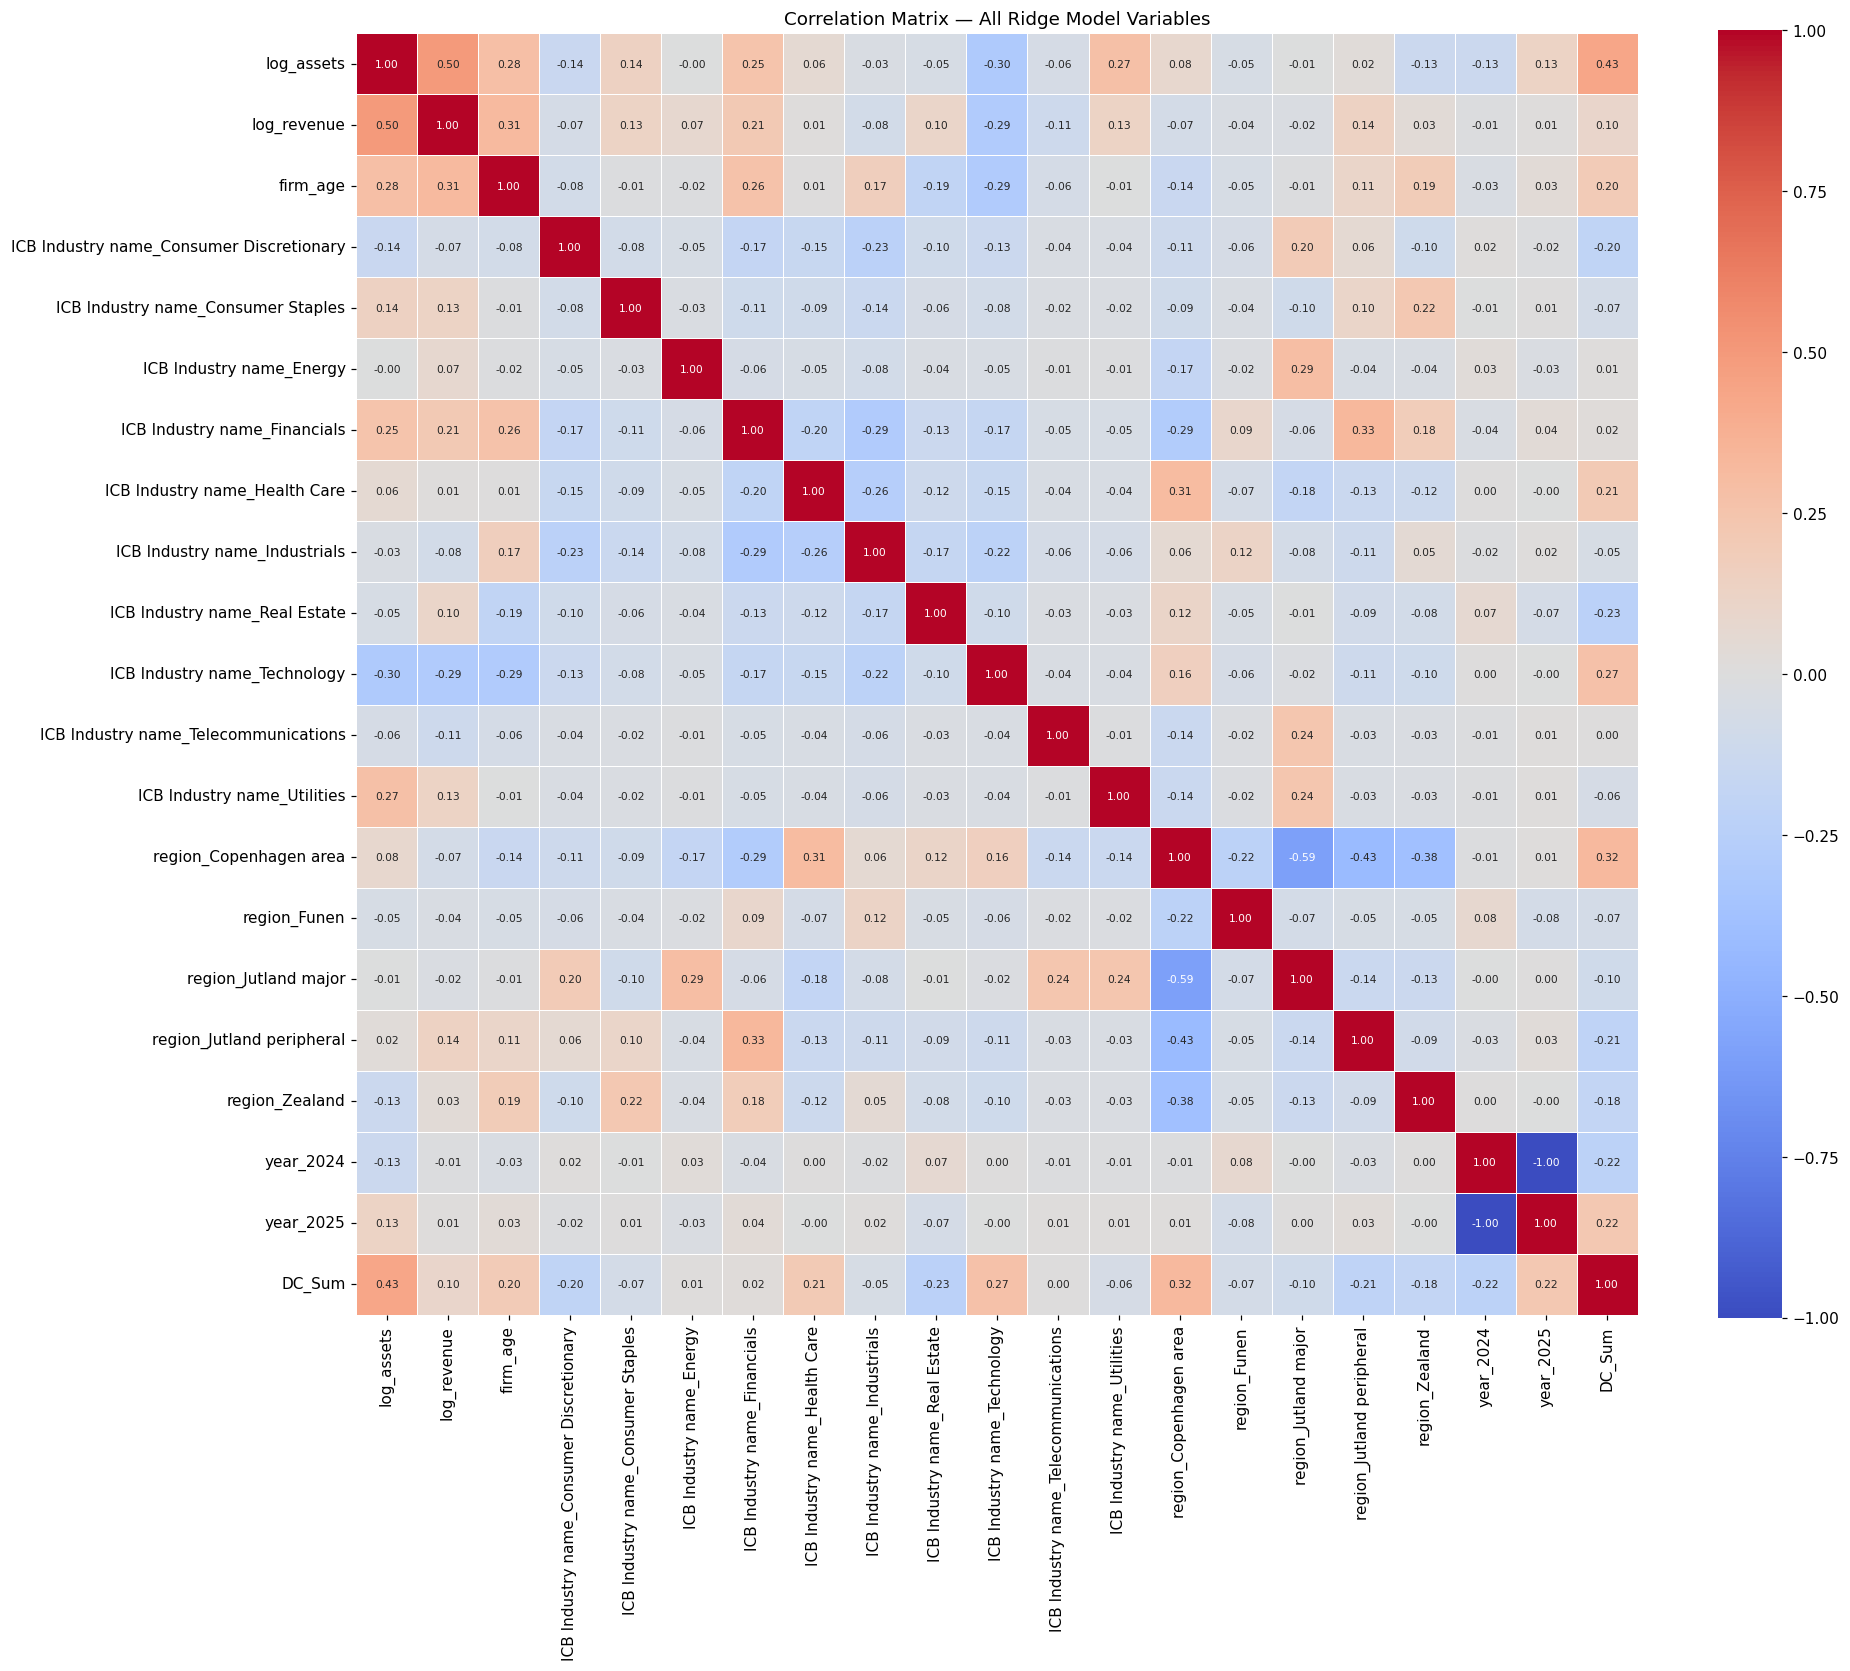

Saved: correlation_matrix_ridge.png


In [9]:
#Correlation matrix (Regression must be run first, otherwise CSV-file is not imported and values are not pre-processed)

import seaborn as sns

corr_df = X_df.copy()
corr_df.columns = [pretty_feat(c) for c in corr_df.columns]
corr_df['DC_Sum'] = y
corr = corr_df.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7})
plt.title("Correlation Matrix — All Ridge Model Variables")
plt.tight_layout()
plt.savefig("correlation_matrix_ridge.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: correlation_matrix_ridge.png")


=== A. DC Sum scatter plots ===


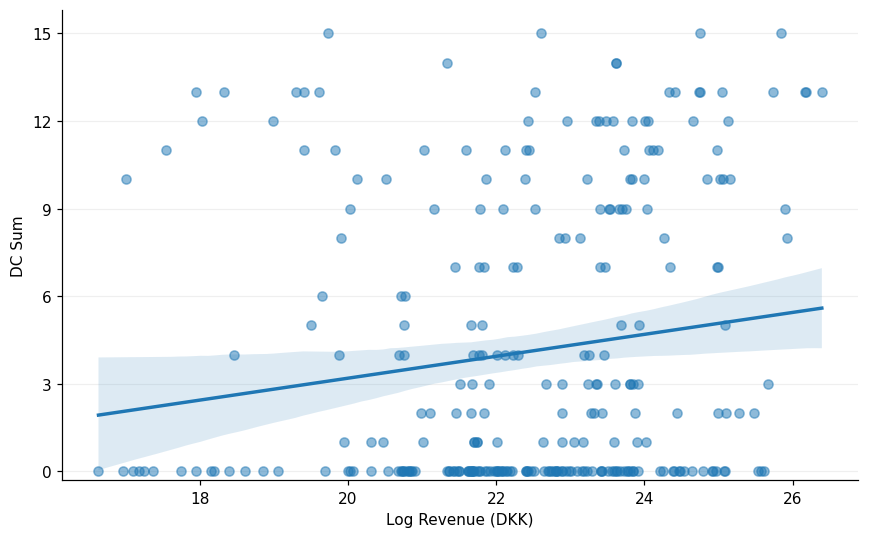

Saved: dc_sum_vs_revenue.png


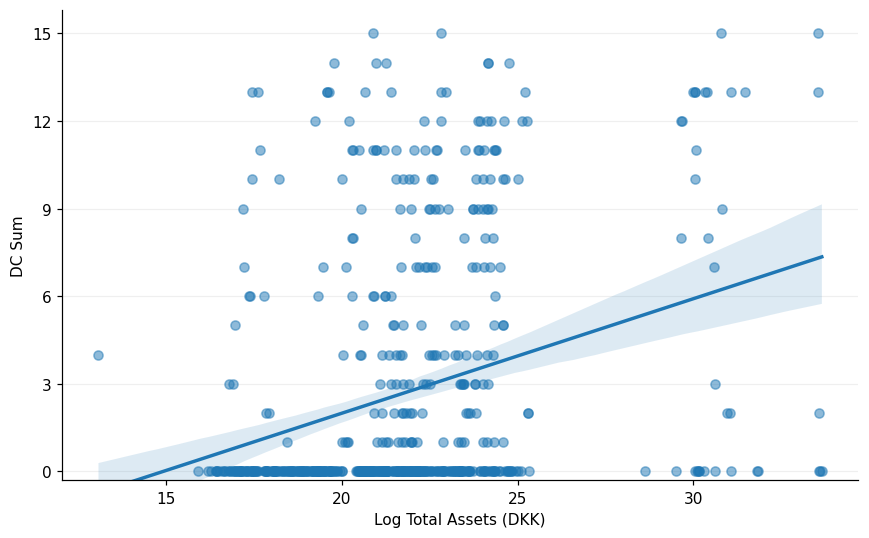

Saved: dc_sum_vs_total_assets.png


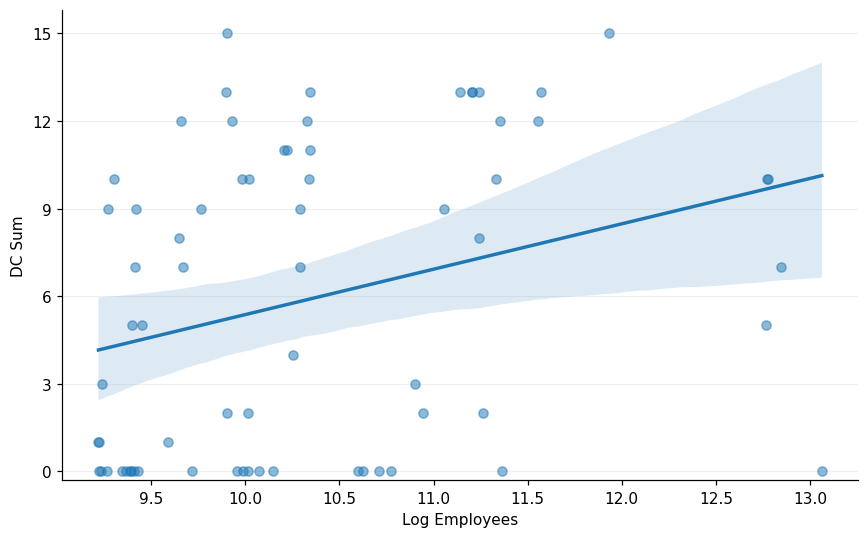

Saved: dc_sum_vs_employees.png


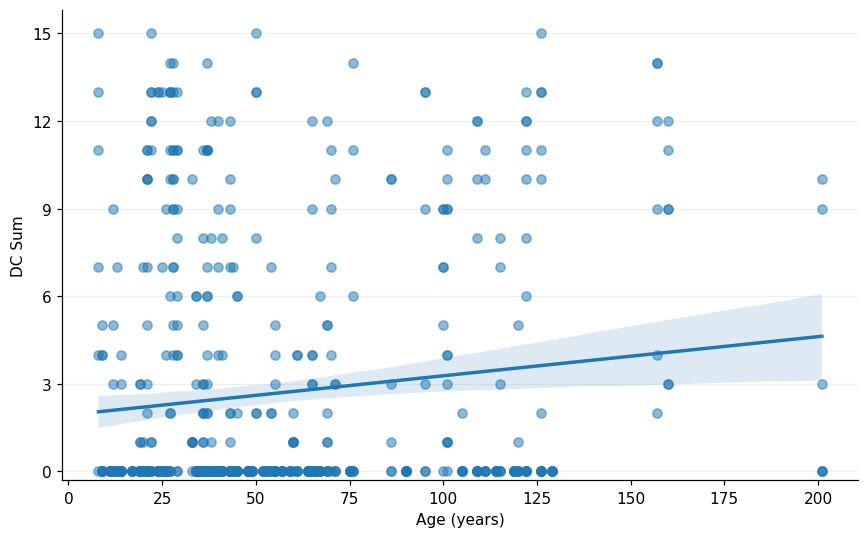

Saved: dc_sum_vs_age.png

=== B. Mean DC Sum over time by grouping ===


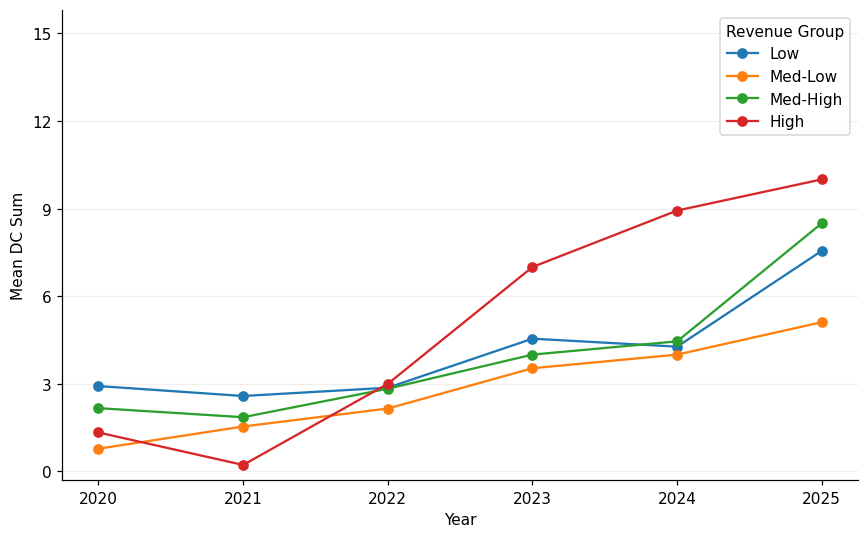

Saved: dc_sum_over_time_by_revenue_group.png


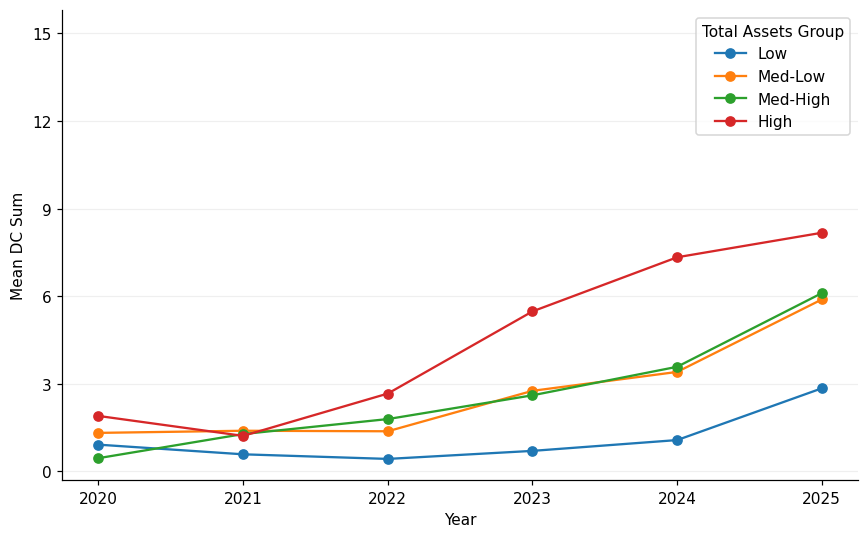

Saved: dc_sum_over_time_by_total_assets_group.png


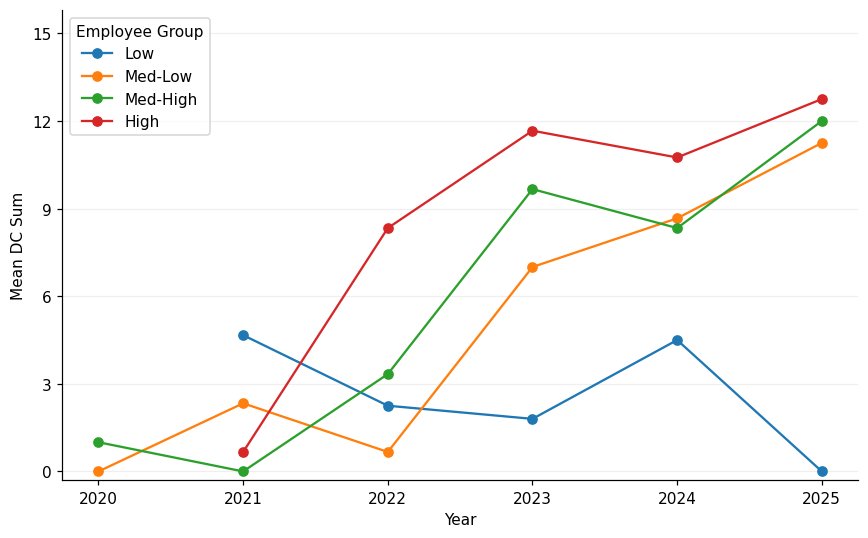

Saved: dc_sum_over_time_by_employee_group.png


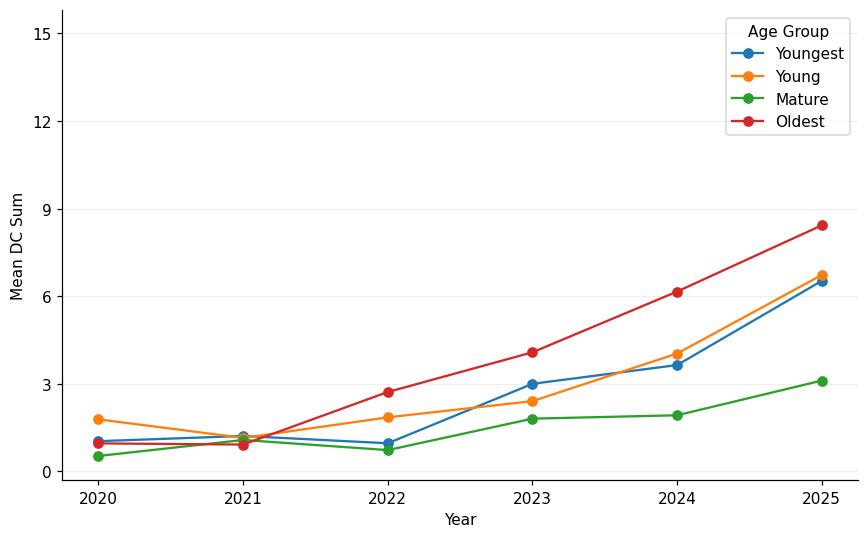

Saved: dc_sum_over_time_by_age_group.png

=== C. Mean DC Sum per Industry over time ===


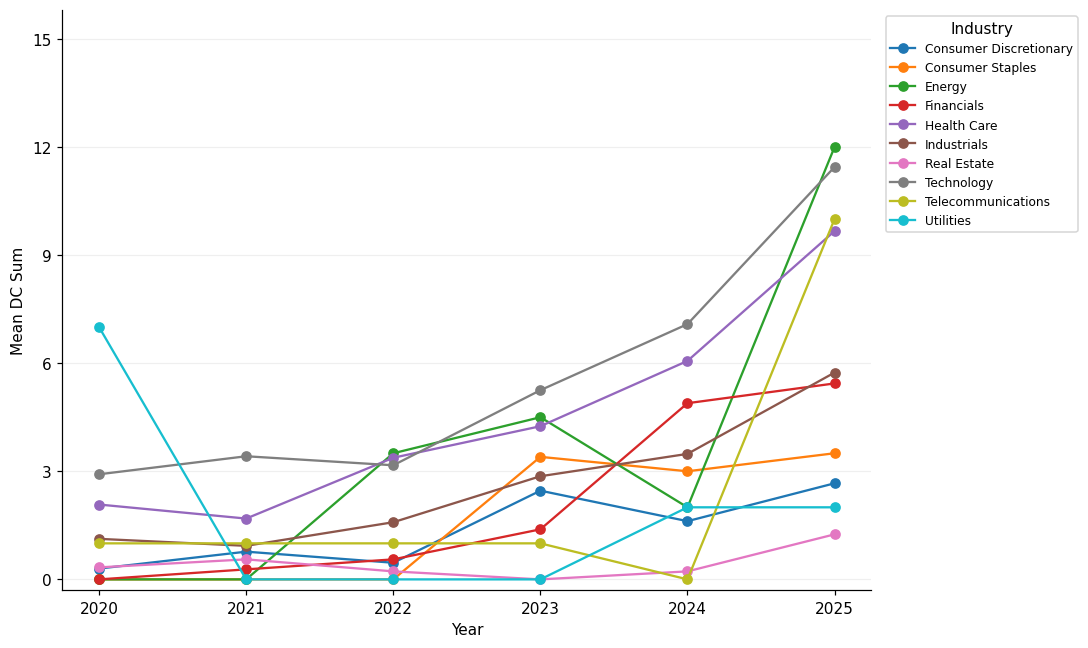

Saved: average_dc_sum_per_industry_over_time.png

=== D. Mean AI Share (%) over time by grouping ===


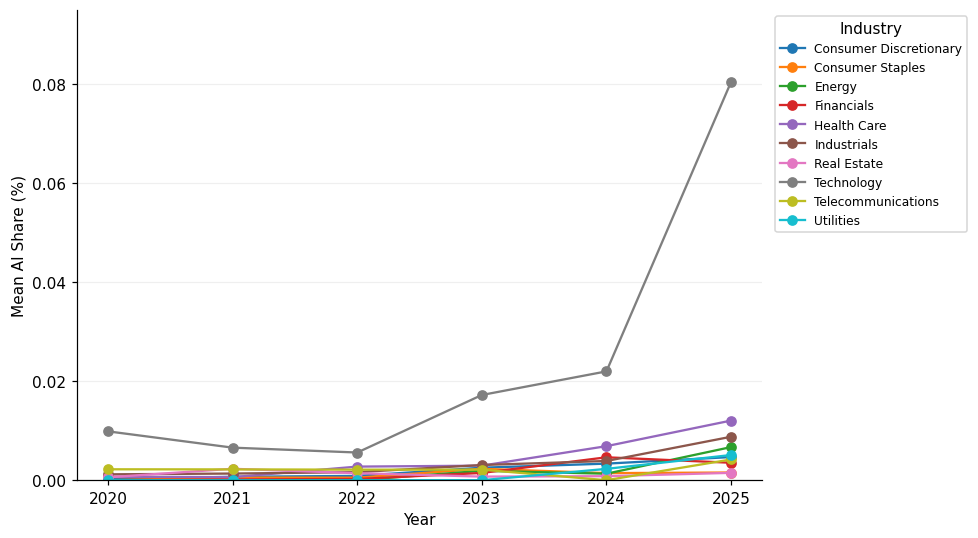

Saved: average_ai_share_pct_over_time_by_industry.png


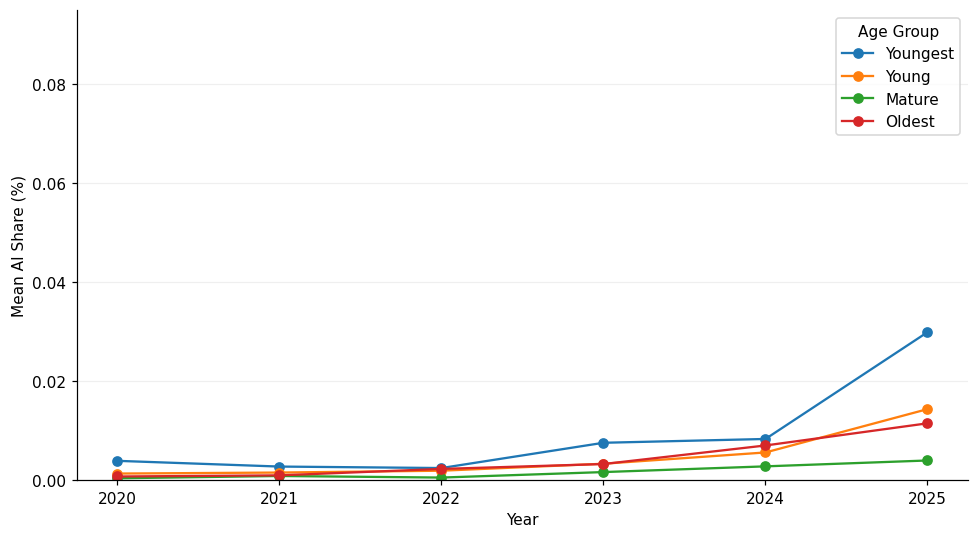

Saved: average_ai_share_pct_over_time_by_age_group.png


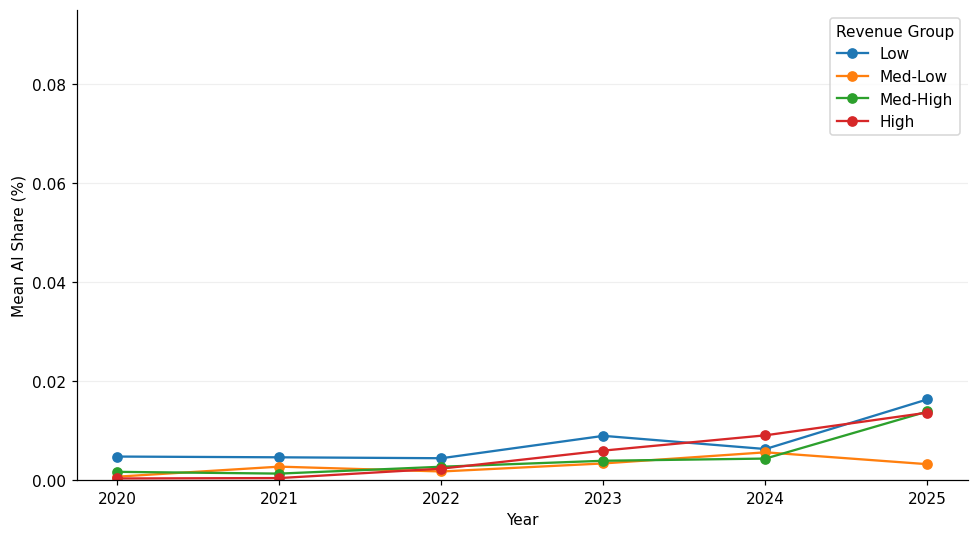

Saved: average_ai_share_pct_over_time_by_revenue_group.png


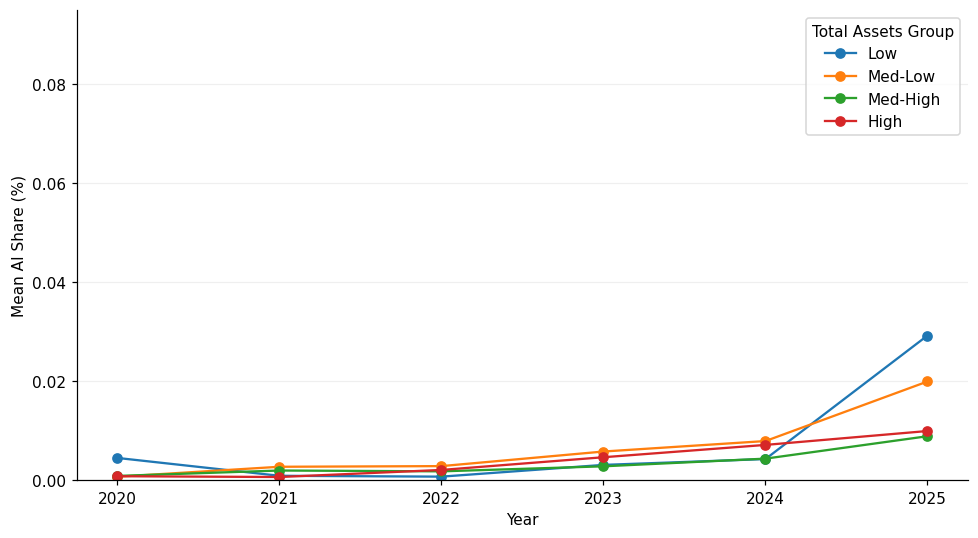

Saved: average_ai_share_pct_over_time_by_total_assets_group.png


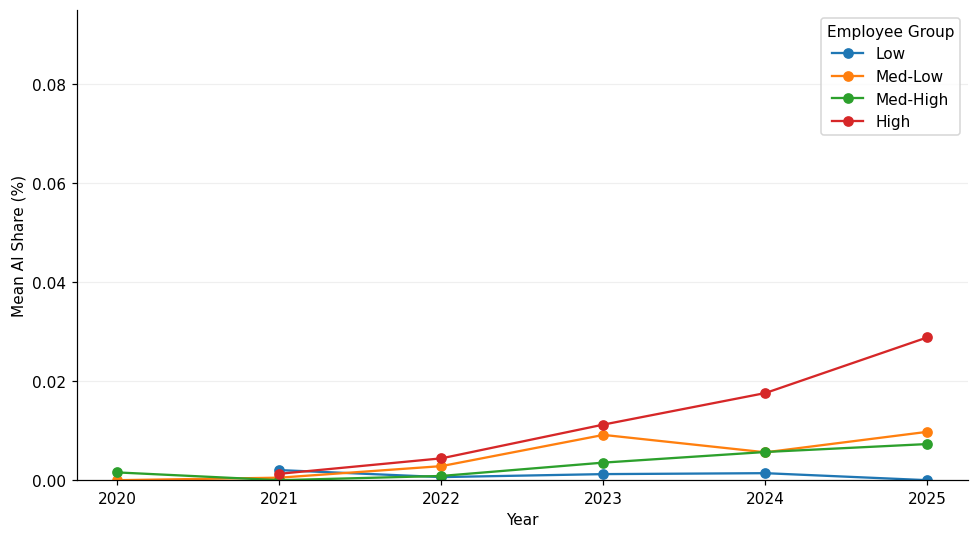

Saved: average_ai_share_pct_over_time_by_employee_group.png

=== E. Sensing / Seizing / Transforming by grouping ===


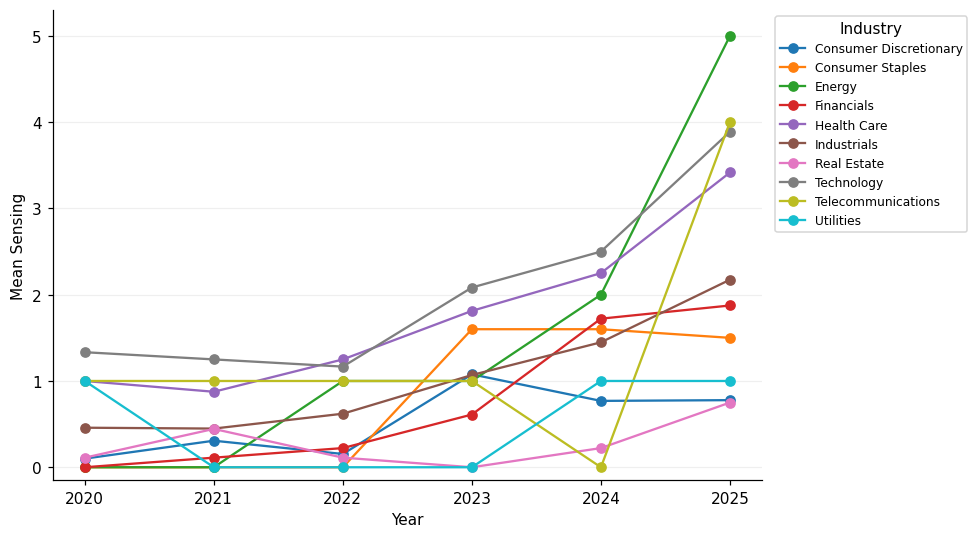

Saved: sensing_over_time_by_industry.png


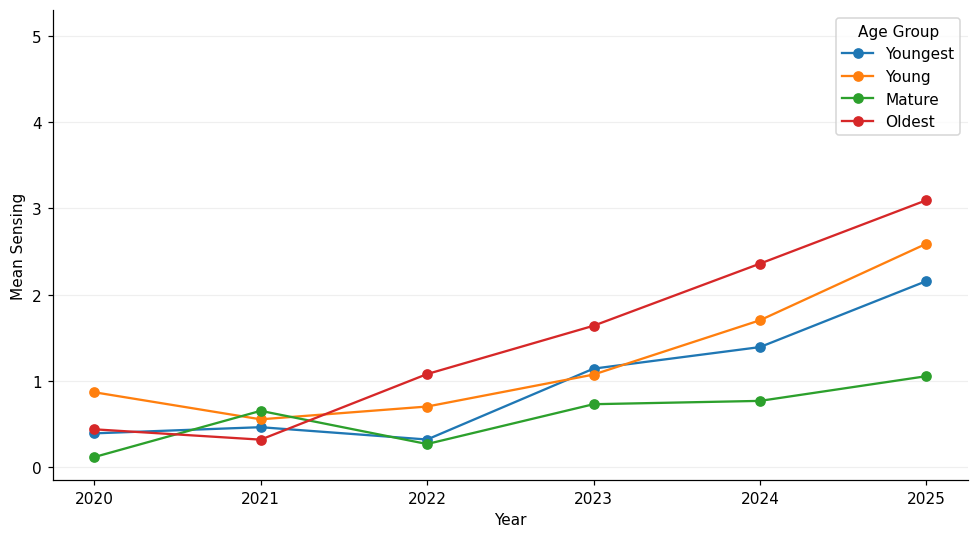

Saved: sensing_over_time_by_age_group.png


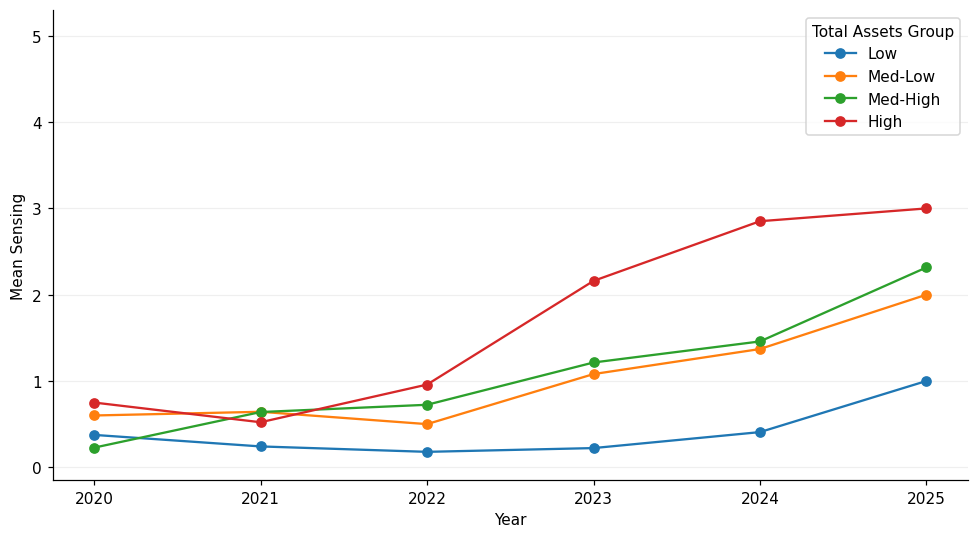

Saved: sensing_over_time_by_total_assets_group.png


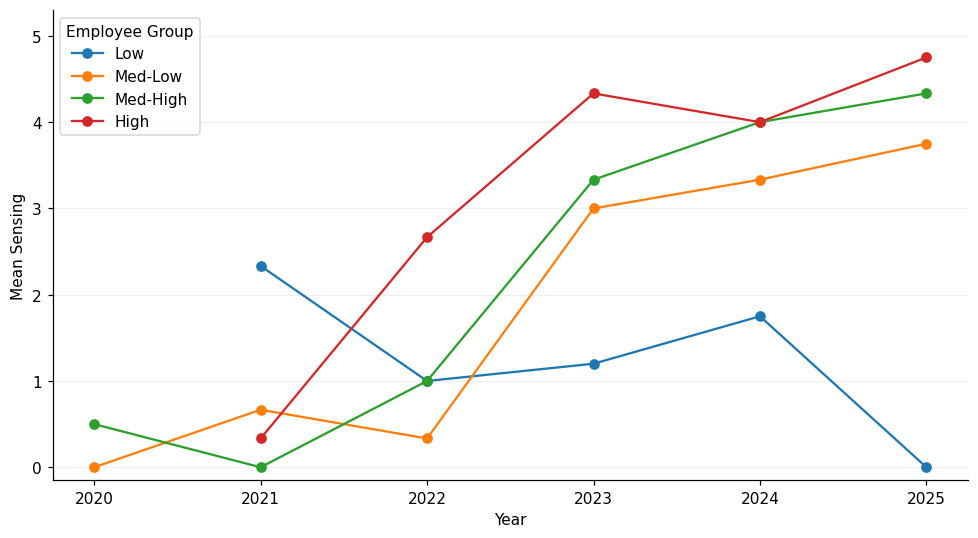

Saved: sensing_over_time_by_employee_group.png


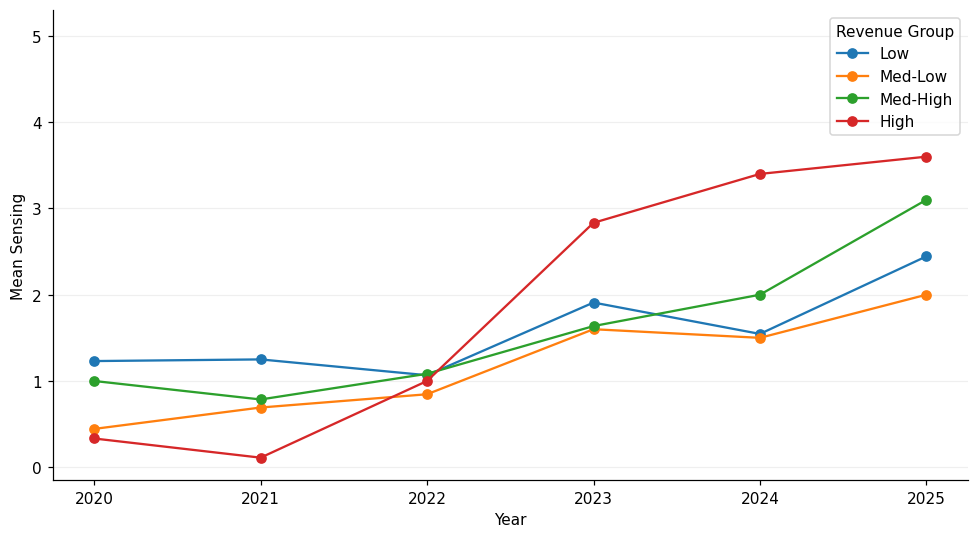

Saved: sensing_over_time_by_revenue_group.png


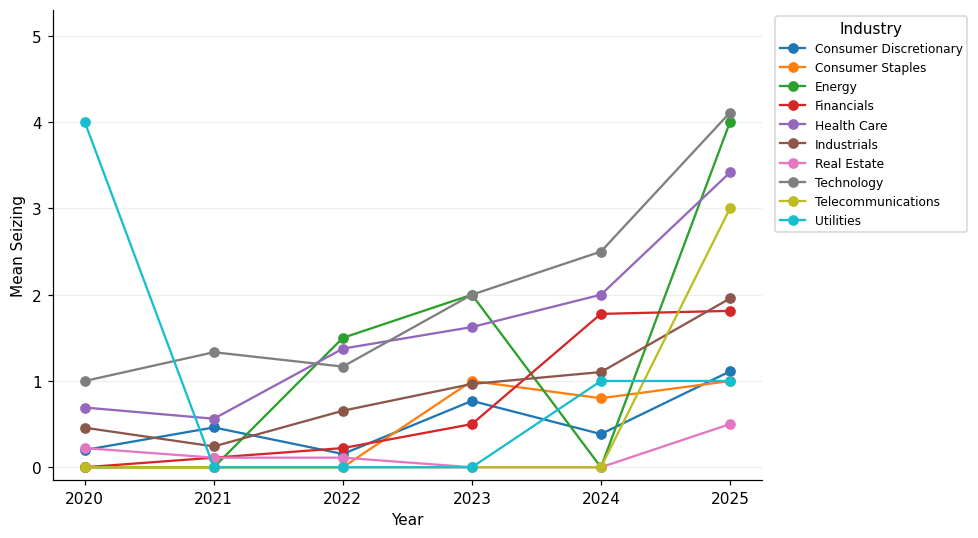

Saved: seizing_over_time_by_industry.png


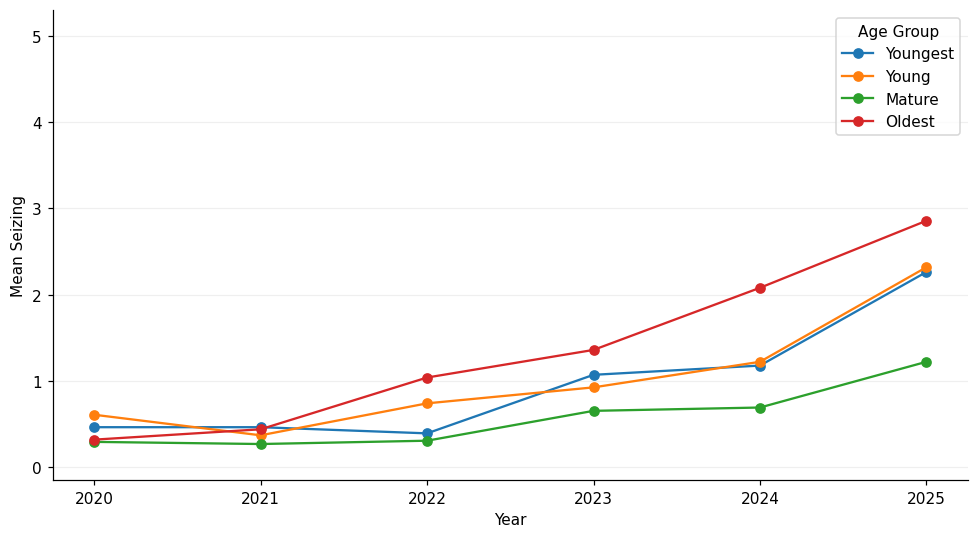

Saved: seizing_over_time_by_age_group.png


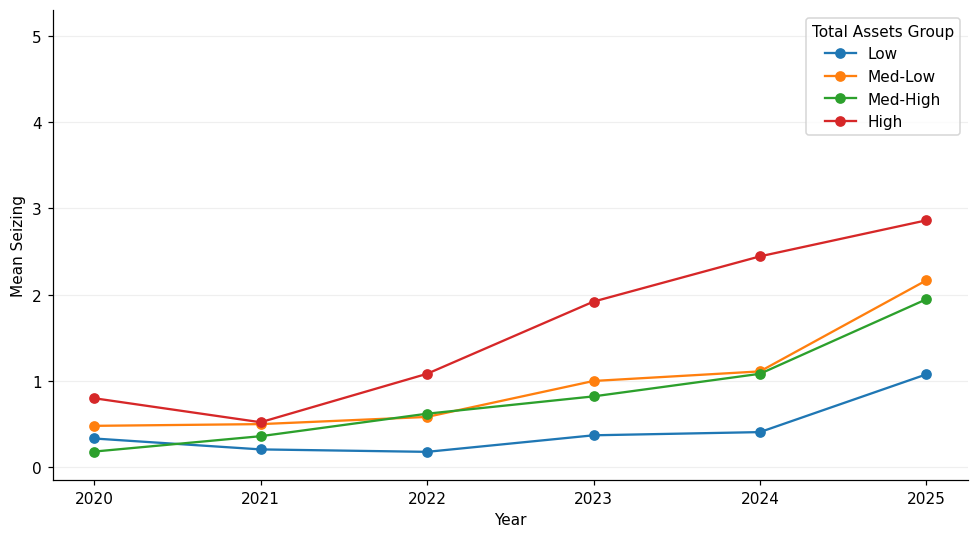

Saved: seizing_over_time_by_total_assets_group.png


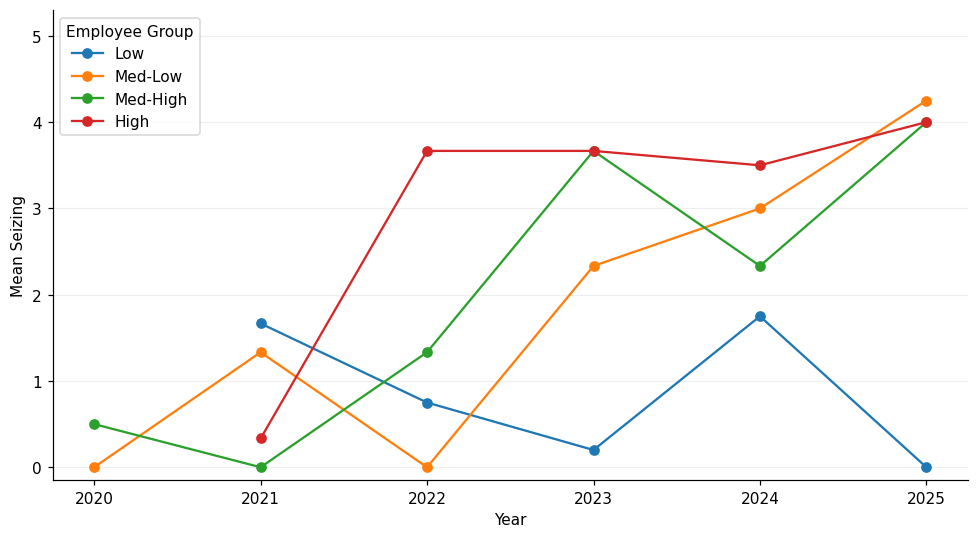

Saved: seizing_over_time_by_employee_group.png


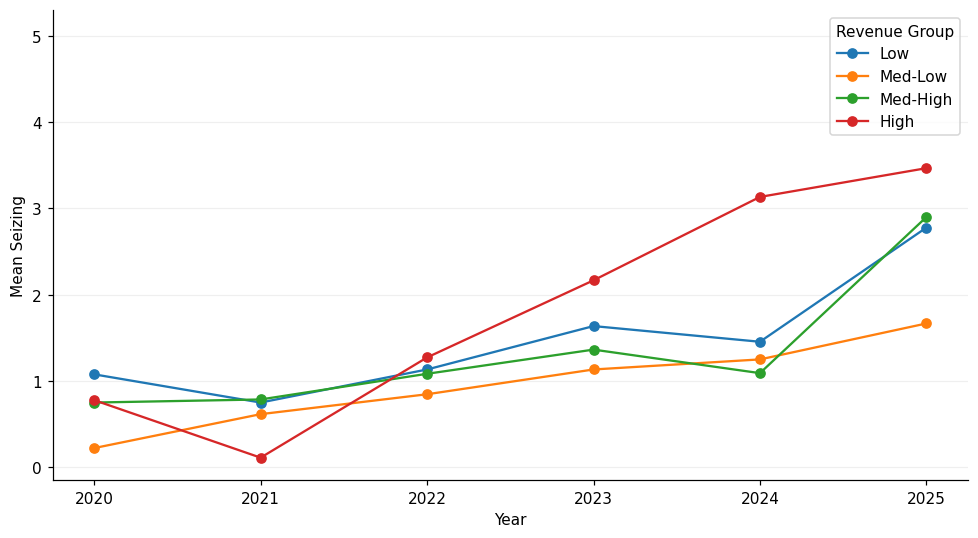

Saved: seizing_over_time_by_revenue_group.png


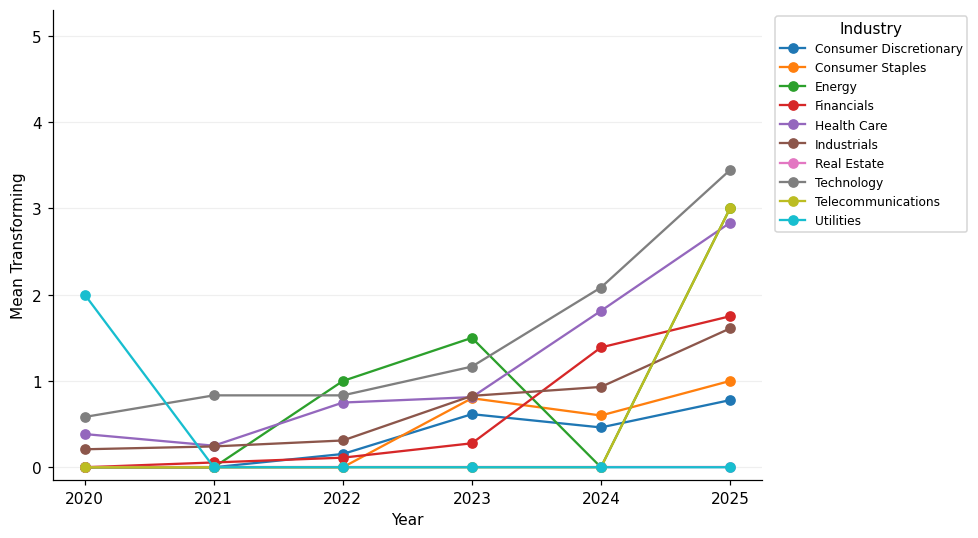

Saved: transforming_over_time_by_industry.png


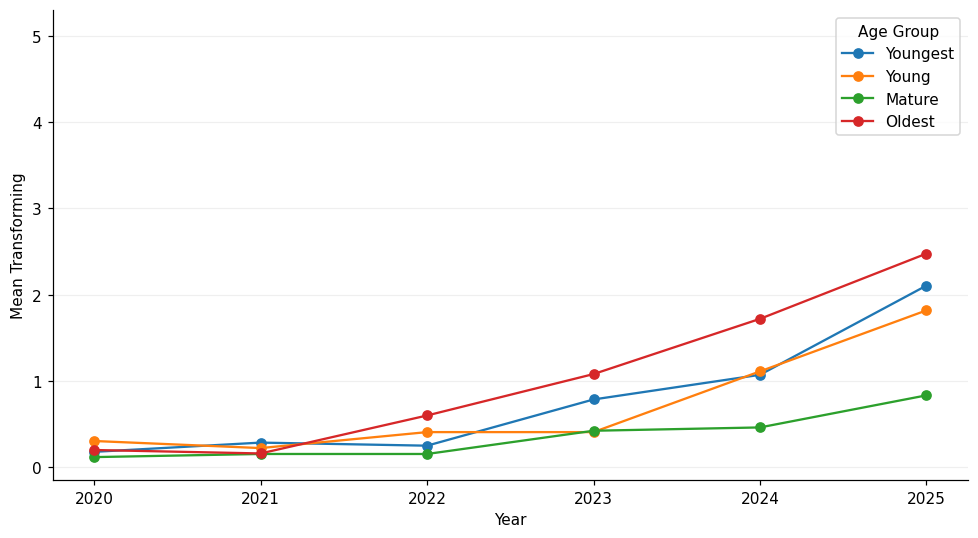

Saved: transforming_over_time_by_age_group.png


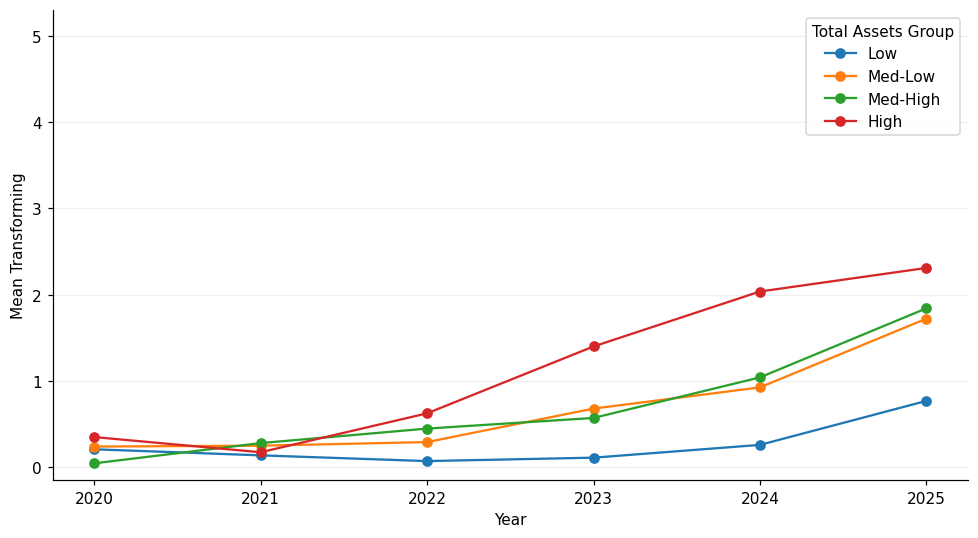

Saved: transforming_over_time_by_total_assets_group.png


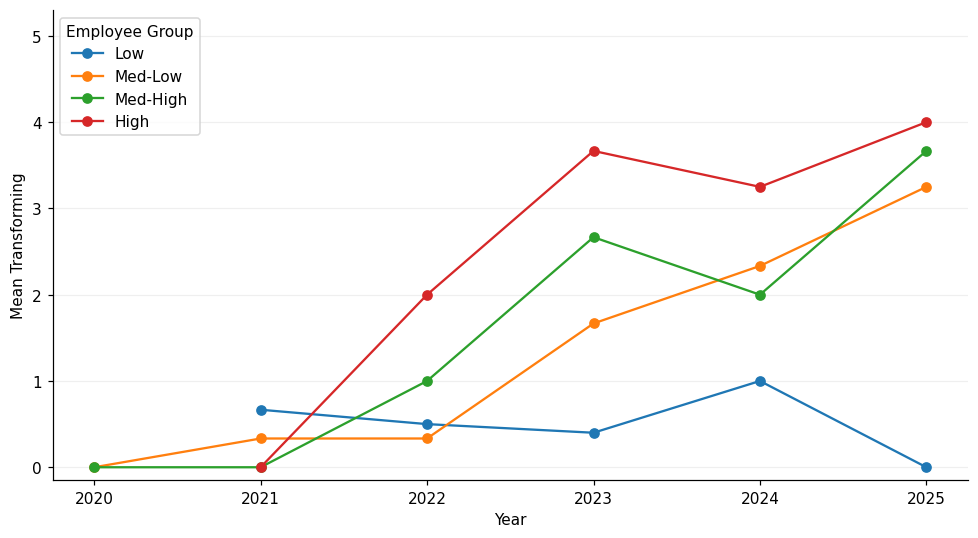

Saved: transforming_over_time_by_employee_group.png


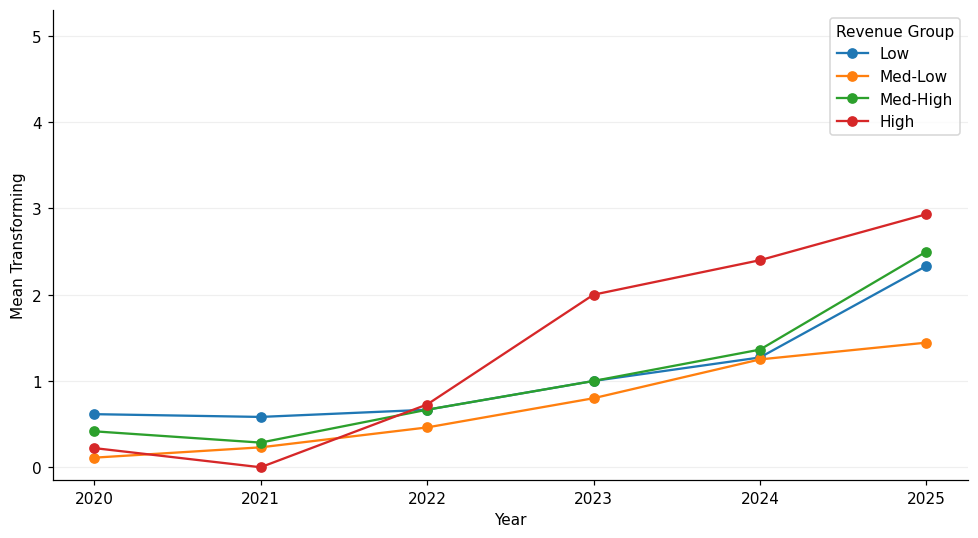

Saved: transforming_over_time_by_revenue_group.png

=== F. Mean Sensing, Seizing, Transforming over time ===


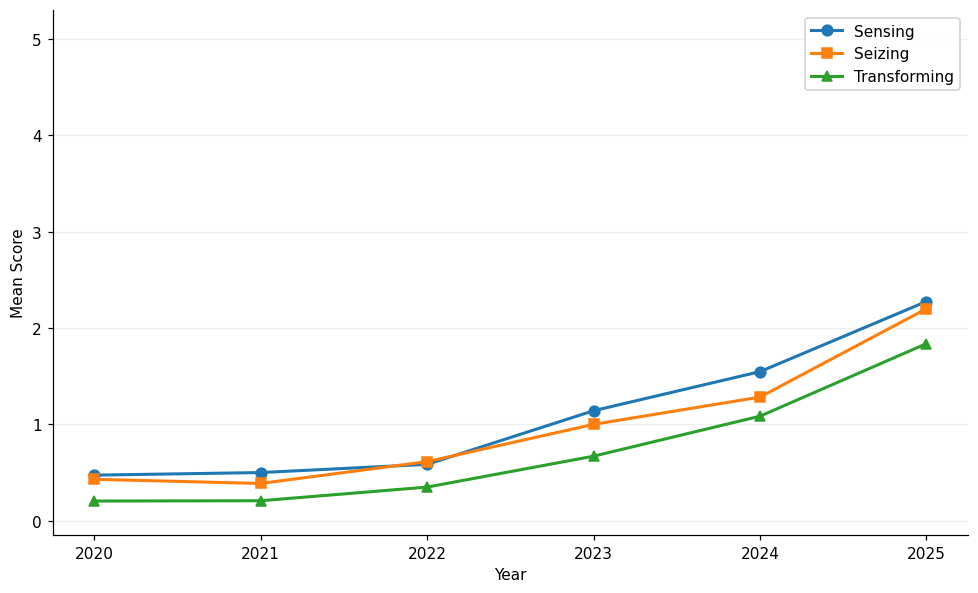

Saved: sensing_seizing_transforming_over_time.png

=== F2. Mean AI Share (%) over time (all firms) ===


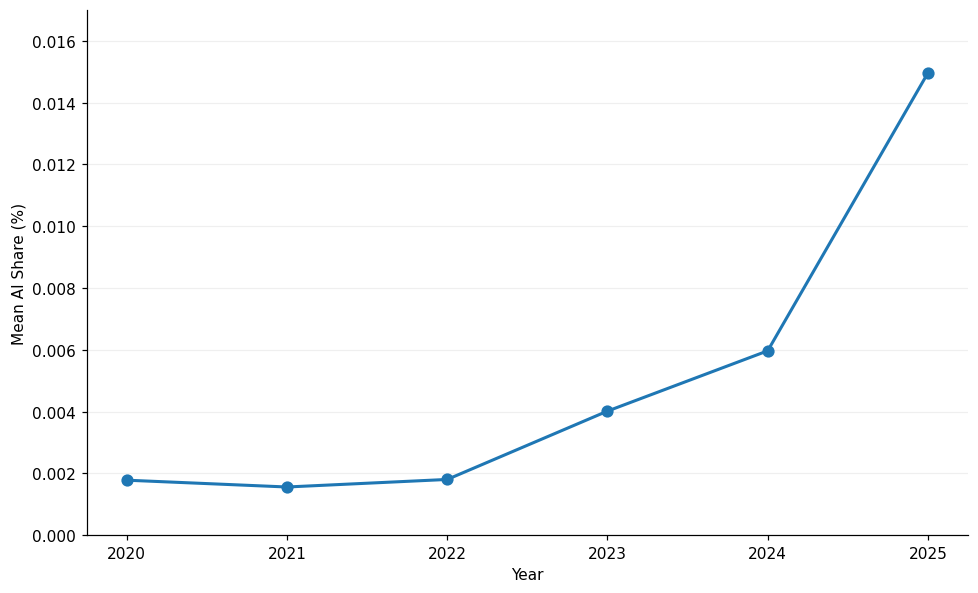

Saved: ai_share_all_firms_over_time.png

=== G. Top 4 DC Sum firms over time ===


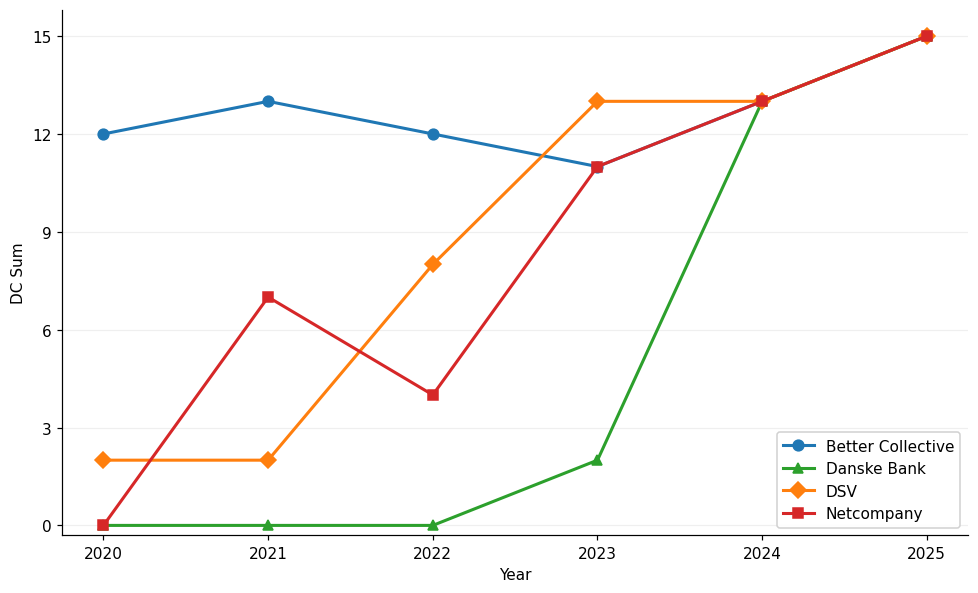

Saved: top4_dc_sum_over_time.png

=== H. Top 5 AI Share (%) firms over time ===


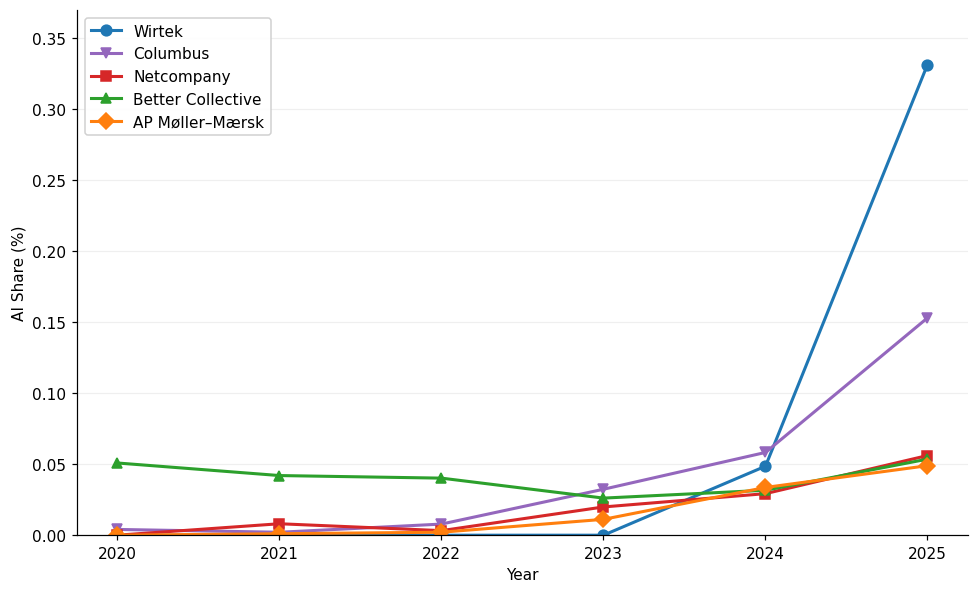

Saved: top5_ai_share_over_time.png

=== I. Top 5 consistent firms over time ===


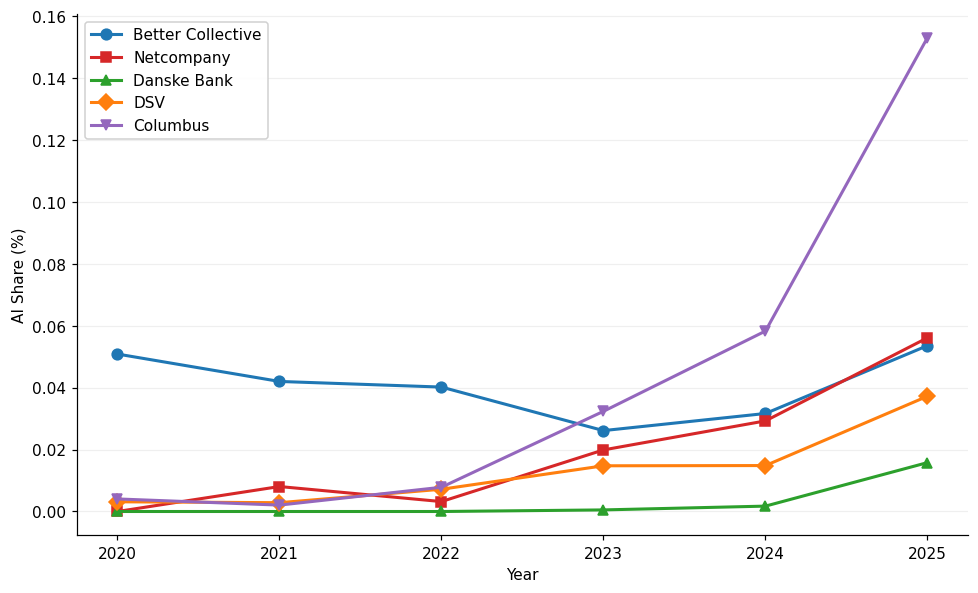

Saved: top5_ai_mention_over_time.png


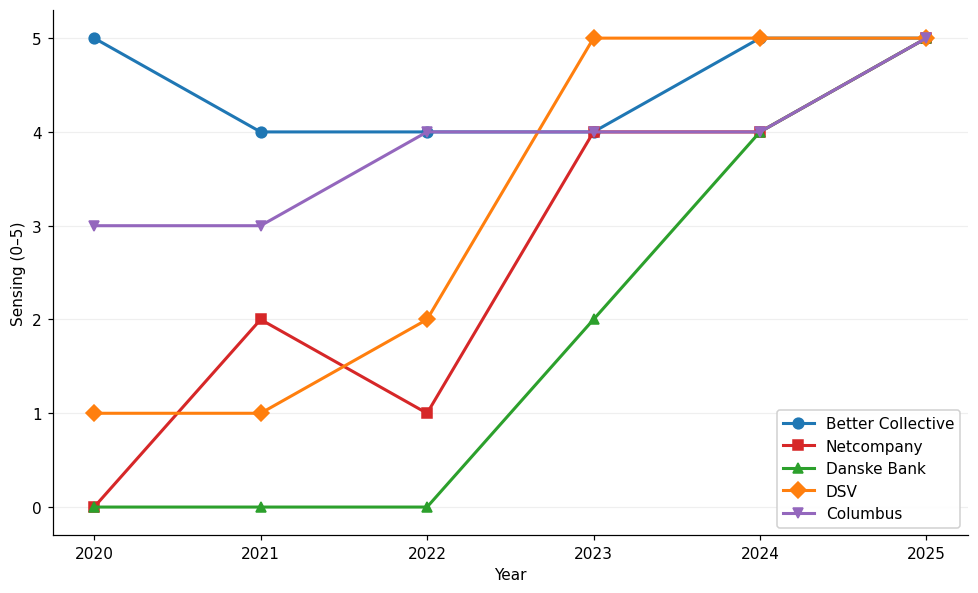

Saved: top5_sensing_over_time.png


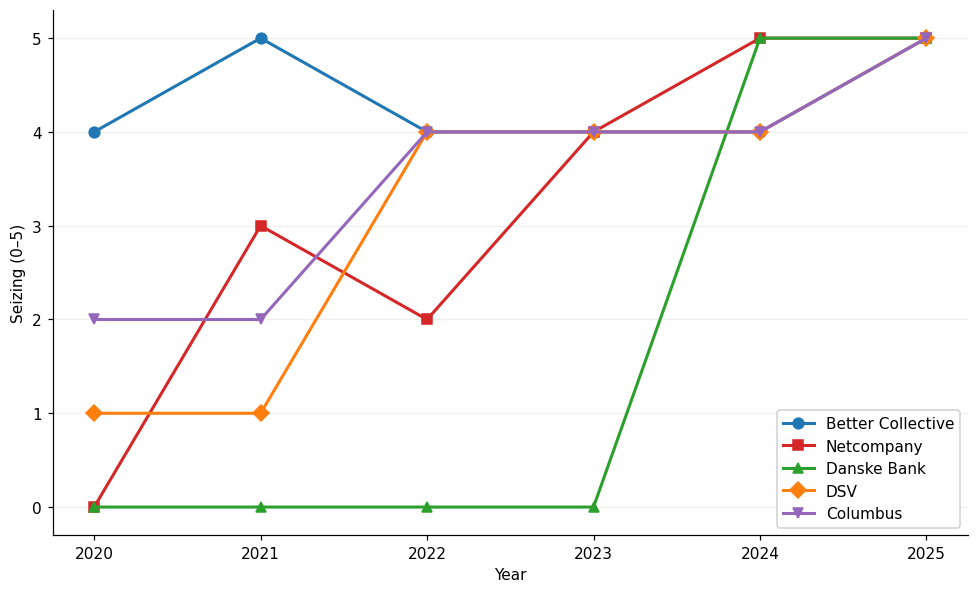

Saved: top5_seizing_over_time.png


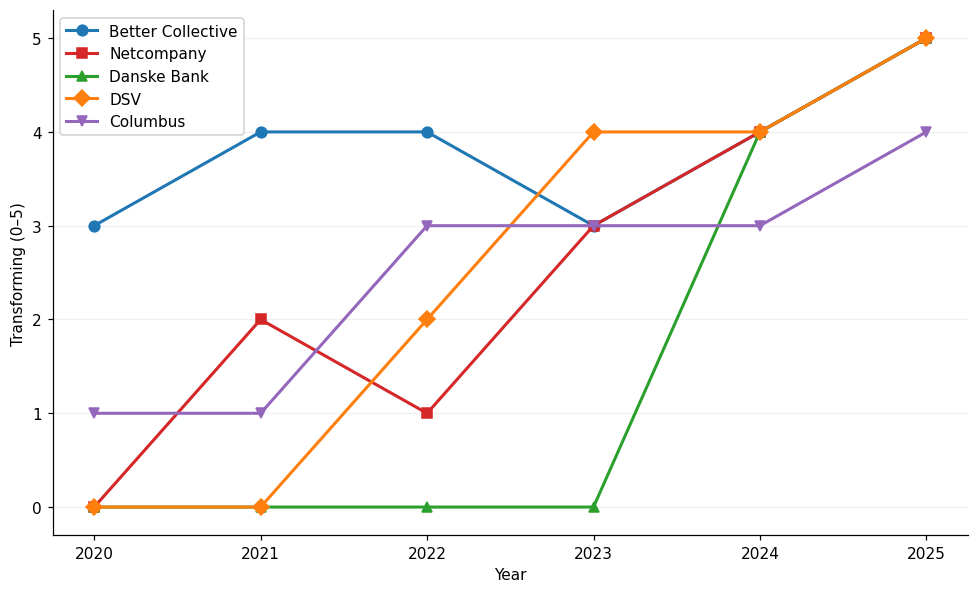

Saved: top5_transforming_over_time.png


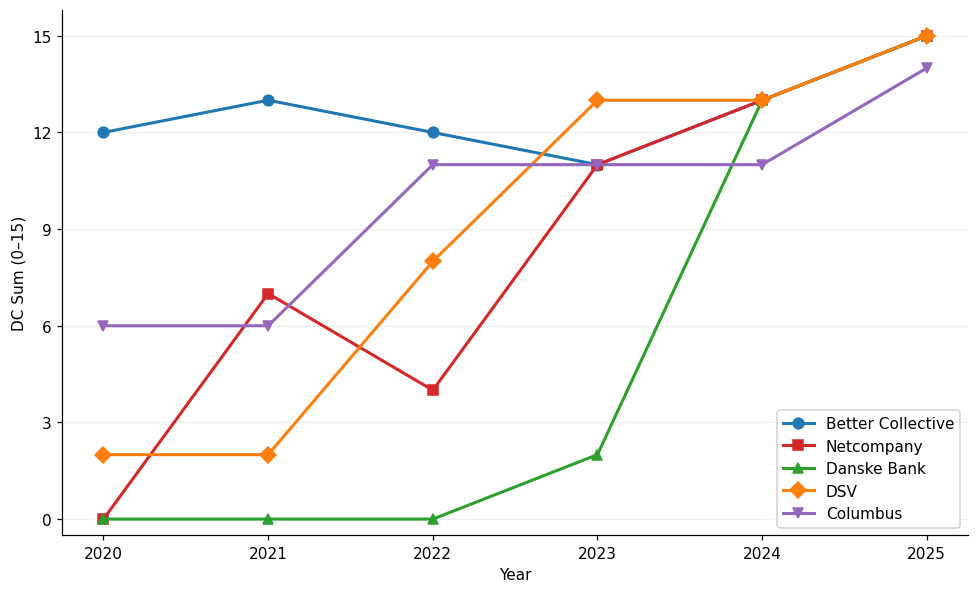

Saved: top5_summed_dc_score_over_time.png

Done — all charts saved.


In [10]:
"""
Complete descriptive graphing suite.

Graphs produced:
  A. DC Sum scatter plots vs Revenue, Assets, Employees, Age        (4 charts)
  B. Mean DC Sum over time by Revenue/Assets/Employees/Age bins     (4 charts)
  C. Mean DC Sum per Industry over time                             (1 chart)
  D. Mean AI Share (%) over time by Industry/Age/Rev/Assets/Empl    (5 charts)
  E. Sensing/Seizing/Transforming × 5 groupings                    (15 charts)
  F. Mean Sensing, Seizing, Transforming over time (3-line chart)   (1 chart)
  G. Top 4 DC Sum firms over time                                   (1 chart)
  H. Top 5 AI Share (%) firms over time                             (1 chart)
  I. Top 5 consistent firms × 5 metrics over time                   (5 charts)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

#Load + clean
df = pd.read_csv('Master.csv', sep=';', encoding='utf-8')

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.strip()
              .str.replace(',', '', regex=False)
              .str.replace(' ', '', regex=False)
              .replace(['nan', 'None', 'N/A', 'NA', '', '-'], np.nan),
        errors='coerce',
    )

df['Revenue_num']   = clean_numeric(df['Revenue'])
df['Assets_num']    = clean_numeric(df['Total Assets Reported'])
df['Employees_num'] = clean_numeric(df['Employees'])

df['Incorp_year'] = pd.to_datetime(
    df['Date of Incorporation'], dayfirst=True, errors='coerce'
).dt.year
df['Age'] = 2026 - df['Incorp_year']

#Define bins for graphs grouped by independent variables
def make_bins(series, labels):
    return pd.qcut(series, q=4, labels=labels, duplicates='drop')

df['Revenue_bin']   = make_bins(df['Revenue_num'],   ['Low', 'Med-Low', 'Med-High', 'High'])
df['Assets_bin']    = make_bins(df['Assets_num'],    ['Low', 'Med-Low', 'Med-High', 'High'])
df['Employees_bin'] = make_bins(df['Employees_num'], ['Low', 'Med-Low', 'Med-High', 'High'])
df['Age_bin']       = make_bins(df['Age'],           ['Youngest', 'Young', 'Mature', 'Oldest'])

#Define layout and graph export
def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='-', alpha=0.2)
    ax.set_axisbelow(True)

def save_fig(filename):
    plt.tight_layout()
    plt.savefig(filename, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

years_all = sorted(df['Year'].dropna().unique().astype(int))

#A. DC Sum scatter plots vs Revenue, Assets, Employees, Age
print('\n=== A. DC Sum scatter plots ===')
scatter_vars = [
    ('Revenue_num',   'Log Revenue (DKK)',      'dc_sum_vs_revenue.png',      True),
    ('Assets_num',    'Log Total Assets (DKK)', 'dc_sum_vs_total_assets.png', True),
    ('Employees_num', 'Log Employees',    'dc_sum_vs_employees.png',    True),
    ('Age',           'Age (years)',      'dc_sum_vs_age.png',          False),
]

for num_col, x_label, filename, log_transform in scatter_vars:
    valid = df[df[num_col].notna() & df['DC_Sum'].notna() & (df[num_col] > 0)].copy()
    if log_transform:
        plot_col = f'log_{num_col}'
        valid[plot_col] = np.log(valid[num_col])
    else:
        plot_col = num_col

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.regplot(x=plot_col, y='DC_Sum', data=valid,
                scatter_kws={'alpha': 0.5}, ax=ax)
    ax.set_ylim(-0.3, 15.8)
    ax.set_yticks(range(0, 16, 3))
    ax.set_xlabel(x_label)
    ax.set_ylabel('DC Sum')
    style_ax(ax)
    save_fig(filename)

#B. Mean DC Sum over time by Revenue/Assets/Employees/Age bins
print('\n=== B. Mean DC Sum over time by grouping ===')
group_vars_dc = [
    ('Revenue_bin',   'Revenue Group',      'dc_sum_over_time_by_revenue_group.png'),
    ('Assets_bin',    'Total Assets Group',  'dc_sum_over_time_by_total_assets_group.png'),
    ('Employees_bin', 'Employee Group',      'dc_sum_over_time_by_employee_group.png'),
    ('Age_bin',       'Age Group',           'dc_sum_over_time_by_age_group.png'),
]

for bin_col, label, filename in group_vars_dc:
    plot_df = (
        df.groupby(['Year', bin_col], observed=True)['DC_Sum']
        .mean().unstack()
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df.plot(marker='o', ax=ax)
    ax.set_ylim(-0.3, 15.8)
    ax.set_yticks(range(0, 16, 3))
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean DC Sum')
    ax.legend(title=label)
    style_ax(ax)
    save_fig(filename)

#C. Mean DC Sum per Industry over time
print('\n=== C. Mean DC Sum per Industry over time ===')
industry_dc = (
    df.dropna(subset=['ICB Industry name'])
    .groupby(['Year', 'ICB Industry name'])['DC_Sum']
    .mean().unstack()
)

fig, ax = plt.subplots(figsize=(10, 6))
industry_dc.plot(marker='o', ax=ax)
ax.set_ylim(-0.3, 15.8)
ax.set_yticks(range(0, 16, 3))
ax.set_xlabel('Year')
ax.set_ylabel('Mean DC Sum')
ax.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
style_ax(ax)
save_fig('average_dc_sum_per_industry_over_time.png')


#D. Mean AI Share (%) over time by grouping
print('\n=== D. Mean AI Share (%) over time by grouping ===')
group_vars_ai = [
    ('ICB Industry name', 'Industry',          False, 'average_ai_share_pct_over_time_by_industry.png'),
    ('Age_bin',           'Age Group',         True,  'average_ai_share_pct_over_time_by_age_group.png'),
    ('Revenue_bin',       'Revenue Group',     True,  'average_ai_share_pct_over_time_by_revenue_group.png'),
    ('Assets_bin',        'Total Assets Group', True,  'average_ai_share_pct_over_time_by_total_assets_group.png'),
    ('Employees_bin',     'Employee Group',    True,  'average_ai_share_pct_over_time_by_employee_group.png'),
]

for group_col, label, observed, filename in group_vars_ai:
    plot_df = (
        df.dropna(subset=[group_col])
        .groupby(['Year', group_col], observed=observed)['AI share']
        .mean().unstack()
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df.plot(marker='o', ax=ax)
    ax.set_ylim(0, 0.095)
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean AI Share (%)')
    if group_col == 'ICB Industry name':
        ax.legend(title=label, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    else:
        ax.legend(title=label)
    style_ax(ax)
    save_fig(filename)


#E. Sensing / Seizing / Transforming — 15 individual charts
print('\n=== E. Sensing / Seizing / Transforming by grouping ===')
dc_components = ['Sensing', 'Seizing', 'Transforming']
component_groups = [
    ('ICB Industry name', 'Industry',          False),
    ('Age_bin',           'Age Group',         True),
    ('Assets_bin',        'Total Assets Group', True),
    ('Employees_bin',     'Employee Group',    True),
    ('Revenue_bin',       'Revenue Group',     True),
]

for component in dc_components:
    for group_col, label, observed in component_groups:
        plot_df = (
            df.dropna(subset=[group_col])
            .groupby(['Year', group_col], observed=observed)[component]
            .mean().unstack()
        )
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_df.plot(marker='o', ax=ax)
        ax.set_ylim(-0.15, 5.3)
        ax.set_yticks(range(0, 6))
        ax.set_xlabel('Year')
        ax.set_ylabel(f'Mean {component}')
        if group_col == 'ICB Industry name':
            ax.legend(title=label, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
        else:
            ax.legend(title=label)
        style_ax(ax)
        filename = f'{component.lower()}_over_time_by_{label.lower().replace(" ", "_")}.png'
        save_fig(filename)

#F. Mean Sensing, Seizing, Transforming over time
print('\n=== F. Mean Sensing, Seizing, Transforming over time ===')
colors_sst = {'Sensing': '#1f77b4', 'Seizing': '#ff7f0e', 'Transforming': '#2ca02c'}
markers_sst = {'Sensing': 'o', 'Seizing': 's', 'Transforming': '^'}

avg_sst = df.groupby('Year')[dc_components].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
for comp in dc_components:
    ax.plot(avg_sst.index, avg_sst[comp],
            marker=markers_sst[comp], markersize=7,
            linewidth=2, color=colors_sst[comp], label=comp)
ax.set_ylim(-0.15, 5.3)
ax.set_yticks(range(0, 6))
ax.set_xticks(years_all)
ax.set_xlabel('Year')
ax.set_ylabel('Mean Score')
ax.legend(frameon=True, framealpha=0.9)
style_ax(ax)
save_fig('sensing_seizing_transforming_over_time.png')


#F2. Mean AI Share (%) of all firms over time
print('\n=== F2. Mean AI Share (%) over time (all firms) ===')
avg_ai = df.groupby('Year')['AI share'].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(avg_ai.index, avg_ai.values, marker='o', markersize=7,
        linewidth=2, color='#1f77b4')
ax.set_xticks(years_all)
ax.set_xlabel('Year')
ax.set_ylabel('Mean AI Share (%)')
ax.set_ylim(0, 0.017)
style_ax(ax)
save_fig('ai_share_all_firms_over_time.png')


#G. Top 4 DC Sum firms over time
print('\n=== G. Top 4 DC Sum firms over time ===')
TOP4_DC = {
    'BETCO.CO':  'Better Collective',
    'DANSKE.CO': 'Danske Bank',
    'DSV.CO':    'DSV',
    'NETCG.CO':  'Netcompany',
}
STYLE_DC = {
    'Better Collective': {'color': '#1f77b4', 'marker': 'o'},
    'Danske Bank':       {'color': '#2ca02c', 'marker': '^'},
    'DSV':               {'color': '#ff7f0e', 'marker': 'D'},
    'Netcompany':        {'color': '#d62728', 'marker': 's'},
}

plot_dc = df[df['Identifier'].isin(TOP4_DC.keys())].copy()
plot_dc['FirmName'] = plot_dc['Identifier'].map(TOP4_DC)

fig, ax = plt.subplots(figsize=(9, 5.5))
for firm in TOP4_DC.values():
    sub = plot_dc[plot_dc['FirmName'] == firm].sort_values('Year')[['Year', 'DC_Sum']].dropna()
    if len(sub):
        ax.plot(sub['Year'], sub['DC_Sum'],
                marker=STYLE_DC[firm]['marker'], markersize=7,
                linewidth=2, color=STYLE_DC[firm]['color'], label=firm)
ax.set_ylim(-0.3, 15.8)
ax.set_yticks(range(0, 16, 3))
ax.set_xticks(years_all)
ax.set_xlabel('Year')
ax.set_ylabel('DC Sum')
ax.legend(loc='best', frameon=True, framealpha=0.9)
style_ax(ax)
save_fig('top4_dc_sum_over_time.png')


# H. Top 5 AI Share (%) firms over time
print('\n=== H. Top 5 AI Share (%) firms over time ===')
TOP5_AI = {
    'WIRTEK.CO':  'Wirtek',
    'COLUM.CO':   'Columbus',
    'NETCG.CO':   'Netcompany',
    'BETCO.CO':   'Better Collective',
    'MAERSKb.CO': 'AP Møller–Mærsk',
}
STYLE_AI = {
    'Wirtek':            {'color': '#1f77b4', 'marker': 'o'},
    'Columbus':          {'color': '#9467bd', 'marker': 'v'},
    'Netcompany':        {'color': '#d62728', 'marker': 's'},
    'Better Collective': {'color': '#2ca02c', 'marker': '^'},
    'AP Møller–Mærsk':   {'color': '#ff7f0e', 'marker': 'D'},
}

plot_ai = df[df['Identifier'].isin(TOP5_AI.keys())].copy()
plot_ai['FirmName'] = plot_ai['Identifier'].map(TOP5_AI)

fig, ax = plt.subplots(figsize=(9, 5.5))
for firm in TOP5_AI.values():
    sub = plot_ai[plot_ai['FirmName'] == firm].sort_values('Year')[['Year', 'AI share']].dropna()
    if len(sub):
        ax.plot(sub['Year'], sub['AI share'],
                marker=STYLE_AI[firm]['marker'], markersize=7,
                linewidth=2, color=STYLE_AI[firm]['color'], label=firm)
ax.set_ylim(0, 0.37)
ax.set_xticks(years_all)
ax.set_xlabel('Year')
ax.set_ylabel('AI Share (%)')
ax.legend(loc='best', frameon=True, framealpha=0.9)
style_ax(ax)
save_fig('top5_ai_share_over_time.png')


#I. Top 5 consistent firms × 5 metrics over time
print('\n=== I. Top 5 consistent firms over time ===')
TOP5_CON = {
    'BETCO.CO':  'Better Collective',
    'NETCG.CO':  'Netcompany',
    'DANSKE.CO': 'Danske Bank',
    'DSV.CO':    'DSV',
    'COLUM.CO':  'Columbus',
}
STYLE_CON = {
    'Better Collective': {'color': '#1f77b4', 'marker': 'o'},
    'Netcompany':        {'color': '#d62728', 'marker': 's'},
    'Danske Bank':       {'color': '#2ca02c', 'marker': '^'},
    'DSV':               {'color': '#ff7f0e', 'marker': 'D'},
    'Columbus':          {'color': '#9467bd', 'marker': 'v'},
}

plot_con = df[df['Identifier'].isin(TOP5_CON.keys())].copy()
plot_con['FirmName'] = plot_con['Identifier'].map(TOP5_CON)

metrics_con = [
    ('AI share',     'AI Share (%)',    'top5_ai_mention_over_time.png'),
    ('Sensing',      'Sensing (0–5)',   'top5_sensing_over_time.png'),
    ('Seizing',      'Seizing (0–5)',   'top5_seizing_over_time.png'),
    ('Transforming', 'Transforming (0–5)', 'top5_transforming_over_time.png'),
    ('DC_Sum',       'DC Sum (0–15)',   'top5_summed_dc_score_over_time.png'),
]

#Formatting for printing
for col, ylabel, filename in metrics_con:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for firm in TOP5_CON.values():
        sub = plot_con[plot_con['FirmName'] == firm].sort_values('Year')[['Year', col]].dropna()
        if len(sub):
            ax.plot(sub['Year'], sub[col],
                    marker=STYLE_CON[firm]['marker'], markersize=7,
                    linewidth=2, color=STYLE_CON[firm]['color'], label=firm)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_xticks(years_all)

    if col in ('Sensing', 'Seizing', 'Transforming'):
        ax.set_ylim(-0.3, 5.3)
        ax.set_yticks(range(0, 6))
    elif col == 'DC_Sum':
        ax.set_ylim(-0.5, 15.8)
        ax.set_yticks(range(0, 16, 3))

    ax.legend(loc='best', frameon=True, framealpha=0.9)
    style_ax(ax)
    save_fig(filename)

print('\nDone — all charts saved.')